In [1]:
# snmf_env

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from matplotlib import cm
import os
import pickle as pkl
import umap

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

from SigProfilerAssignment import Analyzer as Analyze

%matplotlib inline
sns.set_theme(style="whitegrid")
sns.set(rc={'figure.figsize':(10.0,8.27)})


from SigProfilerMatrixGenerator import install as genInstall
genInstall.install('GRCh37')


# LOAD Bootstrapped functions
from pathlib import Path
import sys, os, importlib

# append project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import importlib
from src.processing import bootstrapping as boot
# Reload the module to ensure we have the latest version
importlib.reload(boot)

# --- Get project root dynamically ---
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent



/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tool       | Installed 
-----------------------
curl       | True      
wget       | False     
rsync      | True      


INFO - GRCh37 is already installed.


All reference files have been created.
To proceed with matrix_generation, please provide the path to your vcf files and an appropriate output path.
Installation complete.


# SNMF (Lc = 0.1 and 0.0)
for generation of randomly split fold and bootrstrapping see notebook: 0_preprocess_cellline.ipynb

In [2]:
import os, pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
x_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_count_keepnames")
y_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")

split="split_00"; prefix="M"
X = pd.read_csv(os.path.join(x_root, split, f"Xboot{prefix}_train_all.txt"), sep="\t", index_col=0)
Y = pd.read_csv(os.path.join(y_root, split, f"Yboot{prefix}_train_all.txt"), sep="\t", index_col=0)

print(X.shape, Y.shape)
print("intersection:", len(set(X.columns) & set(Y.columns)))
print("same order:", list(X.columns) == list(Y.columns))


(96, 1200) (4, 1200)
intersection: 1200
same order: True


In [3]:
import os
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# adjust these if you changed folder names
x_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_count_keepnames")
y_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")

split = "split_00"
prefix = "M"  # or "D"

path_X = os.path.join(x_root, split, f"Xboot{prefix}_train_all.txt")
path_Y = os.path.join(y_root, split, f"Yboot{prefix}_train_all.txt")

X = pd.read_csv(path_X, sep="\t", index_col=0)
Y = pd.read_csv(path_Y, sep="\t", index_col=0)

print("X shape:", X.shape, " (rows=96, cols=samples)")
print("Y shape:", Y.shape, " (rows=classes, cols=samples)")

# 1) duplicate column names?
dupX = X.columns[X.columns.duplicated()].tolist()
dupY = Y.columns[Y.columns.duplicated()].tolist()
print("Duplicate X column names:", len(dupX), "examples:", dupX[:10])
print("Duplicate Y column names:", len(dupY), "examples:", dupY[:10])

# 2) set overlap
sx, sy = set(X.columns), set(Y.columns)
print("Intersection:", len(sx & sy))
print("Only in X:", len(sx - sy))
print("Only in Y:", len(sy - sx))

# show a few missing
onlyX = sorted(list(sx - sy))[:20]
onlyY = sorted(list(sy - sx))[:20]
print("Examples only in X:", onlyX)
print("Examples only in Y:", onlyY)

# 3) same order?
same_order = list(X.columns) == list(Y.columns)
print("Same column order:", same_order)

# 4) how many columns would survive if you align like many libs do?
common = [c for c in X.columns if c in sy]
print("Common in X-order:", len(common))


X shape: (96, 1200)  (rows=96, cols=samples)
Y shape: (4, 1200)  (rows=classes, cols=samples)
Duplicate X column names: 0 examples: []
Duplicate Y column names: 0 examples: []
Intersection: 1200
Only in X: 0
Only in Y: 0
Examples only in X: []
Examples only in Y: []
Same column order: True
Common in X-order: 1200


In [4]:
import os, pandas as pd, numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
x_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_count_keepnames")
y_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")

split="split_00"; prefix="M"
X = pd.read_csv(os.path.join(x_root, split, f"Xboot{prefix}_train_all.txt"), sep="\t", index_col=0)
Y = pd.read_csv(os.path.join(y_root, split, f"Yboot{prefix}_train_all.txt"), sep="\t", index_col=0)

# sanity
print("Shapes:", X.shape, Y.shape)
print("Intersection:", len(set(X.columns) & set(Y.columns)))

# totals per sample
tot = X.sum(axis=0)
print("Totals summary:", tot.min(), np.percentile(tot, [1,5,10,50,90,95,99]), tot.max())

# how many are below the cutoff SNMF printed?
cutoff = 9600
bad = (tot < cutoff)
print("Below 9600:", bad.sum())
print("Examples below 9600:", list(tot[bad].sort_values().head(10).index))


Shapes: (96, 1200) (4, 1200)
Intersection: 1200
Totals summary: 26 [  38.99  130.    176.    440.5  1933.9  2302.2  2979.06] 4011
Below 9600: 1200
Examples below 9600: ['RNF168_multinomial_train_fold3.9', 'RNF168_multinomial_train_fold2.28', 'RNF168_multinomial_train_fold2.45', 'RNF168_multinomial_train_fold1.90', 'RNF168_multinomial_train_fold3.41', 'RNF168_multinomial_train_fold2.32', 'ATP2B4_multinomial_train_fold2.14', 'OGG1_multinomial_train_fold1.11', 'RNF168_multinomial_train_fold2.34', 'OGG1_multinomial_train_fold3.41']


In [5]:
# Mutation counts
print(tot.mean(), tot.median())
len(tot)

785.4925 440.5


1200

# TMB vs 'Background signal'

In [ ]:
# Load count

# Real 

# 

In [ ]:
# Remove avg. ATP2B4 profile from others (leave ATP2B4 in dataset?)


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parents[1]
raw_path = project_root / "data" / "raw" / "zou2021" / "zou_96SBS_filtered.pkl"
raw_df = pd.read_pickle(raw_path)

outdir = project_root / "analysis" / "ung_background_plots"
outdir.mkdir(parents=True, exist_ok=True)

GENE_UNG = "UNG"
GENE_BG  = "ATP2B4"

meta_cols = {"Gene_KO", "Protein_KO", "Subpathway_KO", "Count"}
sbs_cols = [c for c in raw_df.columns if c not in meta_cols and isinstance(c, str) and ("[" in c and "]" in c)]
assert len(sbs_cols) >= 96, f"Expected SBS96 columns; found {len(sbs_cols)}"

Xrel = raw_df[sbs_cols].astype(float).copy()
gene = raw_df["Gene_KO"].astype(str).copy()

# Use Count as absolute TMB
TMB = pd.to_numeric(raw_df["Count"], errors="coerce").fillna(0.0).astype(float).values

# C>A channels from relative profile
ca_cols = [c for c in sbs_cols if "C>A" in c]
assert len(ca_cols) > 0, "No SBS columns contain 'C>A'"

CA_frac = Xrel[ca_cols].sum(axis=1).values                      # relative fraction of C>A
CA_abs  = CA_frac * TMB                                        # absolute number of C>A mutations

metrics = pd.DataFrame({
    "row_id": np.arange(len(raw_df)),
    "gene": gene.values,
    "TMB": TMB,
    "CA_frac": CA_frac,
    "CA_abs": CA_abs,
    "Subpathway_KO": raw_df["Subpathway_KO"].astype(str).values if "Subpathway_KO" in raw_df.columns else "NA",
})
metrics.to_csv(outdir / "raw_df_CA_metrics_using_Count_as_TMB.csv", index=False)

# -----------------------
# Plot helpers
# -----------------------
# Hardcoded gene colors
gene_to_color = {
    "ATP2B4": "#1f77b4",  # Control (blue)
    "EXO1":   "#ad0101",  # HR (true red)
    "RNF168": "#ff2f14",  # HR (bright crimson)
    "UNG":    "#ffd500",  # BER (bright orange)
    "OGG1":   "#ff7b00",  # BER (deep orange)
    "MLH1":   "#33a833",  # MMR (bright green)
    "MSH2":   "#00ff55",  # MMR (lime green)
    "MSH6":   "#47f6d6",  # MMR (light mint)
    "PMS1":   "#8A8B8A",
    "PMS2":   "#4C4C4C",
}

def gene_alpha(gene):
    # Full opacity for control + UNG, faded for all others
    return 1.0 if gene in {"ATP2B4", "UNG"} else 0.6

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def scatter_by_gene(df, x, y, title, fname, show=True):
    fig, ax = plt.subplots()

    legend_handles = {}

    for g, sub in df.groupby("gene"):
        # Convert to 1D numeric arrays and drop NaNs *jointly*
        xvals = pd.to_numeric(sub[x], errors="coerce").to_numpy().ravel()
        yvals = pd.to_numeric(sub[y], errors="coerce").to_numpy().ravel()

        m = np.isfinite(xvals) & np.isfinite(yvals)
        xvals = xvals[m]
        yvals = yvals[m]

        # Safety: if something is still off, skip this group
        if xvals.shape[0] != yvals.shape[0] or xvals.shape[0] == 0:
            continue

        color = gene_to_color.get(g, "#B0B0B0")
        alpha = gene_alpha(g)

        sc = ax.scatter(
            xvals, yvals,
            color=color,
            alpha=alpha,
            s=50,
            edgecolor="none",
        )

        if g in gene_to_color and g not in legend_handles:
            legend_handles[g] = sc

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

    # start axes at 0
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    # black spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.2)

    ax.tick_params(axis="both", colors="black")

    if legend_handles:
        ax.legend(
            legend_handles.values(),
            legend_handles.keys(),
            fontsize=12,
            markerscale=1.5,
            frameon=False,
            ncol=2,
        )

    fig.tight_layout()

    # save
    fig.savefig(outdir / fname, dpi=200)

    # show inline (Jupyter)
    if show:
        plt.show()
    else:
        plt.close(fig)






def scatter_highlight(df, x, y, title, fname):
    plt.figure()
    plt.scatter(df[x], df[y], alpha=0.25)
    for g in [GENE_UNG, GENE_BG]:
        sub = df[df["gene"] == g]
        if len(sub) > 0:
            plt.scatter(sub[x], sub[y], alpha=0.9, label=g)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    if (df["gene"].isin([GENE_UNG, GENE_BG])).any():
        plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / fname, dpi=200)
    plt.close()

def box_three_groups(df, value_col, title, fname):
    df2 = df.copy()
    df2["group"] = np.where(df2["gene"] == GENE_UNG, GENE_UNG,
                     np.where(df2["gene"] == GENE_BG,  GENE_BG, "Other"))
    groups = [df2[df2["group"]==g][value_col].values for g in [GENE_UNG, GENE_BG, "Other"]]
    plt.figure(figsize=(7,4))
    plt.boxplot(groups, labels=[GENE_UNG, GENE_BG, "Other"], showfliers=False)
    plt.ylabel(value_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outdir / fname, dpi=200)
    plt.close()

# -----------------------
# Plots: absolute and relative
# -----------------------
scatter_highlight(metrics, "TMB", "CA_abs",  "Absolute C>A mutations vs TMB (Count)", "A1_CA_abs_vs_TMB.png")
scatter_highlight(metrics, "TMB", "CA_frac", "C>A fraction vs TMB (from profile)",   "A2_CA_frac_vs_TMB.png")
box_three_groups(metrics, "CA_frac", "C>A fraction across gene groups", "A3_CA_frac_box.png")
box_three_groups(metrics, "CA_abs",  "Absolute C>A counts across gene groups", "A4_CA_abs_box.png")

# -----------------------
# Similarity to mean ATP2B4 profile (still using relative profile)
# -----------------------
bg_mask = (metrics["gene"].values == GENE_BG)
if bg_mask.sum() == 0:
    print("WARNING: No ATP2B4 rows found; skipping ATP2B4 similarity plots.")
else:
    bg_profile = Xrel.loc[bg_mask, :].mean(axis=0).values
    bg_norm = np.linalg.norm(bg_profile) + 1e-12
    X_mat = Xrel.values
    x_norm = np.linalg.norm(X_mat, axis=1) + 1e-12
    cos_sim = (X_mat @ bg_profile) / (x_norm * bg_norm)

    metrics["cos_sim_to_ATP2B4_mean"] = cos_sim
    metrics.to_csv(outdir / "raw_df_CA_metrics_with_ATP2B4_similarity.csv", index=False)

    scatter_highlight(metrics, "cos_sim_to_ATP2B4_mean", "CA_frac",
                      "C>A fraction vs similarity to mean ATP2B4 profile",
                      "B1_CAfrac_vs_similarity_to_ATP2B4.png")
    scatter_highlight(metrics, "cos_sim_to_ATP2B4_mean", "CA_abs",
                      "Absolute C>A vs similarity to mean ATP2B4 profile",
                      "B2_CAabs_vs_similarity_to_ATP2B4.png")

print(f"Saved plots + metrics to: {outdir}")


Saved plots + metrics to: /Users/sande/Projects/SNMF/analysis/ung_background_plots


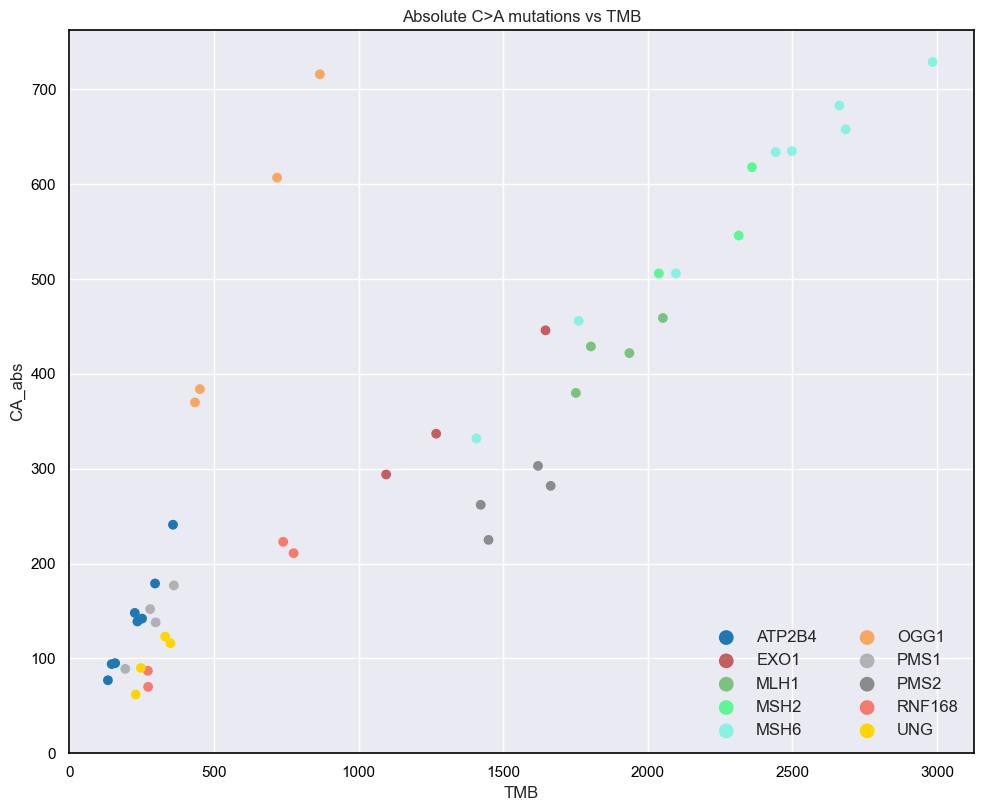

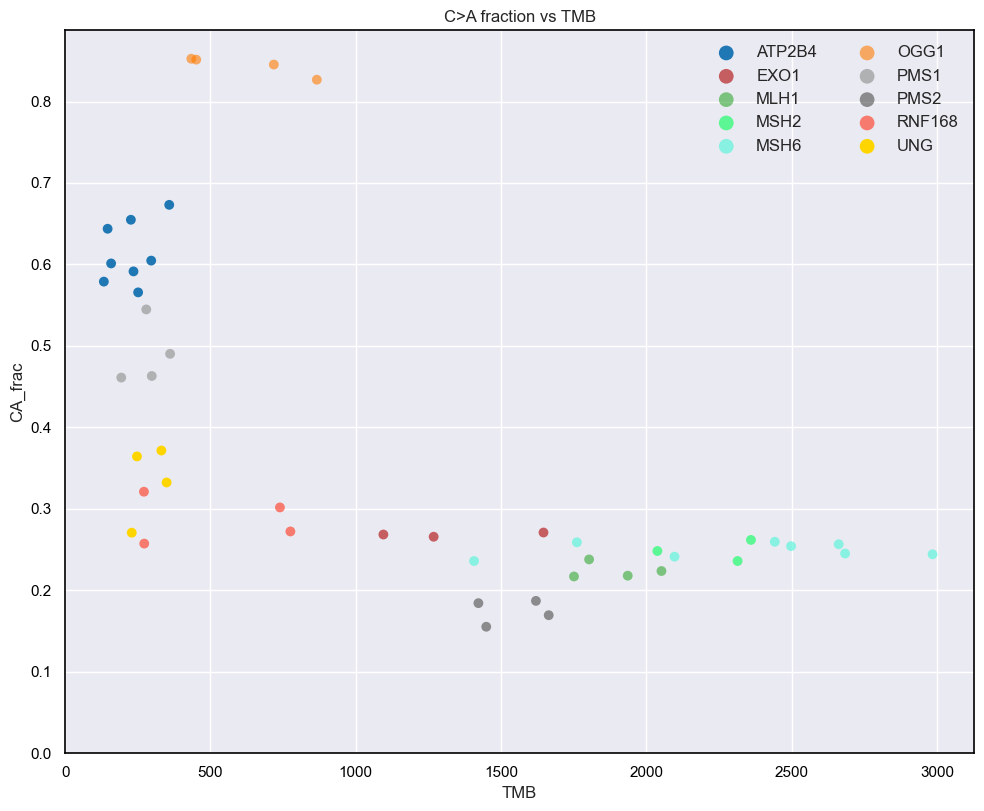

In [7]:
scatter_by_gene(
    metrics,
    x="TMB",
    y="CA_abs",
    title="Absolute C>A mutations vs TMB",
    fname="A1_CA_abs_vs_TMB.png",
)

scatter_by_gene(
    metrics,
    x="TMB",
    y="CA_frac",
    title="C>A fraction vs TMB",
    fname="A2_CA_frac_vs_TMB.png",
)


In [12]:
summary['gene'].unique()

array(['OGG1', 'ATP2B4', 'PMS1', 'UNG', 'RNF168', 'EXO1', 'MSH6', 'MSH2',
       'MLH1', 'PMS2'], dtype=object)

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# Clean CA_frac
metrics_clean = metrics.copy()
metrics_clean["CA_frac"] = pd.to_numeric(metrics_clean["CA_frac"], errors="coerce")
metrics_clean = metrics_clean[np.isfinite(metrics_clean["CA_frac"])]

# ---- Summary per gene ----
summary = (
    metrics_clean
    .groupby("gene")["CA_frac"]
    .agg(
        n="count",
        median="median",
        q25=lambda x: np.percentile(x, 25),
        q75=lambda x: np.percentile(x, 75),
        mean="mean",
        sd="std"
    )
    .reset_index()
)

# Optional: sort alphabetically
summary = summary.sort_values("gene")

# Round for clean presentation
summary_rounded = summary.copy()
summary_rounded[["median","q25","q75","mean","sd"]] = \
    summary_rounded[["median","q25","q75","mean","sd"]].round(4)

# Create IQR column
summary_rounded["IQR"] = (
    summary_rounded["q25"].astype(str) + " – " +
    summary_rounded["q75"].astype(str)
)

# Final table columns
summary_table = summary_rounded[[
    "gene", "n", "median", "IQR", "mean", "sd"
]]

print(summary_table.to_string(index=False))
summary

  gene  n  median             IQR   mean     sd
ATP2B4  8  0.6030 0.5884 – 0.6466 0.6143 0.0385
  EXO1  3  0.2685 0.2671 – 0.2697 0.2684 0.0026
  MLH1  4  0.2208 0.2177 – 0.2272 0.2242 0.0096
  MSH2  3  0.2483 0.2421 – 0.2551 0.2487 0.0130
  MSH6  8  0.2497 0.2435 – 0.2572 0.2495 0.0090
  OGG1  4  0.8484 0.8408 – 0.8517 0.8440 0.0119
  PMS1  4  0.4767 0.4626 – 0.5039 0.4898 0.0390
  PMS2  4  0.1769 0.1659 – 0.1849 0.1740 0.0147
RNF168  4  0.2870 0.2685 – 0.3066 0.2881 0.0287
   UNG  4  0.3484  0.317 – 0.3662 0.3348 0.0460


,gene,n,median,q25,q75,mean,sd
0,ATP2B4,8,0.602998,0.588354,0.646594,0.614257,0.038499
1,EXO1,3,0.268493,0.267133,0.269727,0.268409,0.002595
2,MLH1,4,0.220830,0.217736,0.227247,0.224154,0.009648
3,MSH2,3,0.248283,0.242119,0.255074,0.248701,0.012960
4,MSH6,8,0.249680,0.243490,0.257166,0.249498,0.008953
5,OGG1,4,0.848423,0.840750,0.851715,0.844042,0.011921
6,PMS1,4,0.476696,0.462600,0.503929,0.489834,0.038989
7,PMS2,4,0.176859,0.165923,0.184945,0.174009,0.014674
8,RNF168,4,0.287009,0.268532,0.306578,0.288101,0.028679
9,UNG,4,0.348375,0.316969,0.366180,0.334774,0.045964


In [15]:
genes_of_interest = ["OGG1", "ATP2B4", "PMS1", "UNG"]
all_genes = [
    'OGG1', 'ATP2B4', 'PMS1', 'UNG',
    'RNF168', 'EXO1', 'MSH6', 'MSH2',
    'MLH1', 'PMS2'
]

results = []

for g in genes_of_interest:
    g_vals = metrics_clean.loc[metrics_clean["gene"] == g, "CA_frac"]
    other_genes = [x for x in all_genes if x != g]
    bg_vals = metrics_clean.loc[
        metrics_clean["gene"].isin(other_genes), "CA_frac"
    ]
    
    stat, pval = mannwhitneyu(g_vals, bg_vals, alternative="two-sided")
    
    results.append({
        "gene": g,
        "n_gene": len(g_vals),
        "n_background": len(bg_vals),
        "median_gene": np.median(g_vals),
        "median_background": np.median(bg_vals),
        "p_value": pval
    })

results_df = pd.DataFrame(results)

# Round nicely
results_df[["median_gene","median_background","p_value"]] = \
    results_df[["median_gene","median_background","p_value"]].round(4)

print(results_df.to_string(index=False))

  gene  n_gene  n_background  median_gene  median_background  p_value
  OGG1       4            42       0.8484             0.2671   0.0000
ATP2B4       8            38       0.6030             0.2607   0.0002
  PMS1       4            42       0.4767             0.2671   0.1729
   UNG       4            42       0.3484             0.2671   0.5596


In [16]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

genes_of_interest = ["OGG1", "ATP2B4", "PMS1", "UNG"]
background_genes = ["RNF168", "EXO1", "MSH6", "MSH2", "MLH1", "PMS2"]

results = []

# Pre-extract background once (fixed)
bg_vals = metrics_clean.loc[
    metrics_clean["gene"].isin(background_genes),
    "CA_frac"
]

for g in genes_of_interest:
    g_vals = metrics_clean.loc[
        metrics_clean["gene"] == g,
        "CA_frac"
    ]
    
    stat, pval = mannwhitneyu(g_vals, bg_vals, alternative="two-sided")
    
    results.append({
        "gene": g,
        "n_gene": len(g_vals),
        "n_background": len(bg_vals),
        "median_gene": np.median(g_vals),
        "median_background": np.median(bg_vals),
        "p_value": pval
    })

results_df = pd.DataFrame(results)

# Round for presentation
results_df[["median_gene","median_background","p_value"]] = \
    results_df[["median_gene","median_background","p_value"]].round(4)

print(results_df.to_string(index=False))

  gene  n_gene  n_background  median_gene  median_background  p_value
  OGG1       4            26       0.8484             0.2467   0.0001
ATP2B4       8            26       0.6030             0.2467   0.0000
  PMS1       4            26       0.4767             0.2467   0.0001
   UNG       4            26       0.3484             0.2467   0.0009


## Subtract ATP2B4 'Background' count from other genes

After subtraction:
           TMB_sub  CA_abs_sub  CA_frac_sub
gene                                       
ATP2B4   54.265625    25.37500     0.333526
UNG     126.062500     3.40625     0.025425


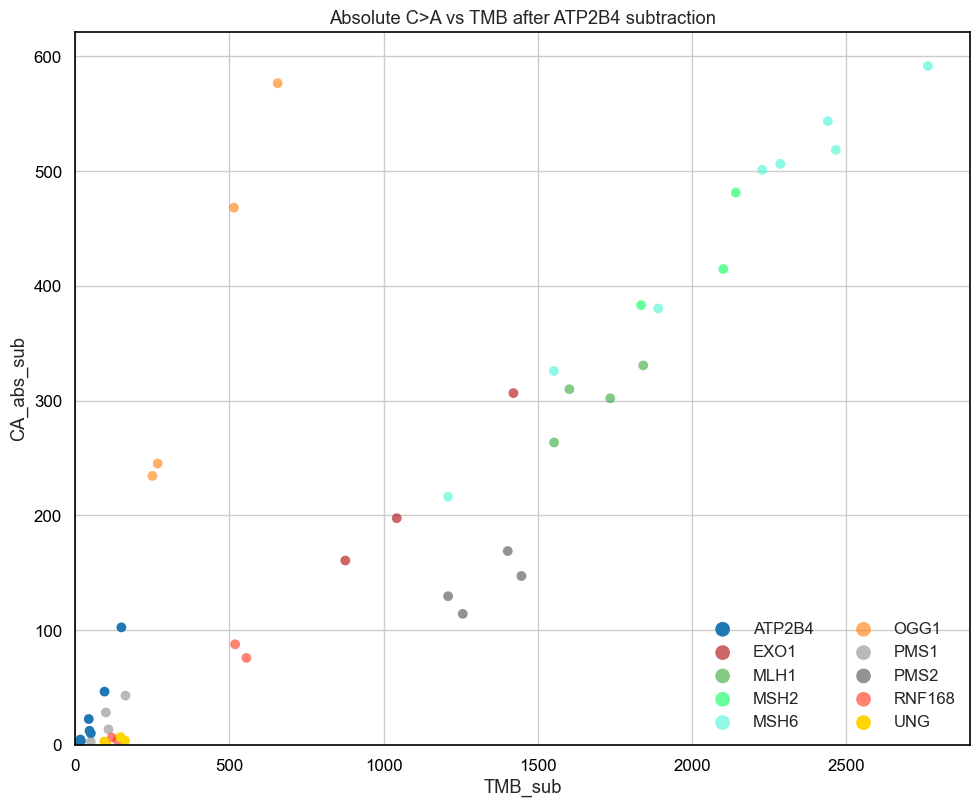

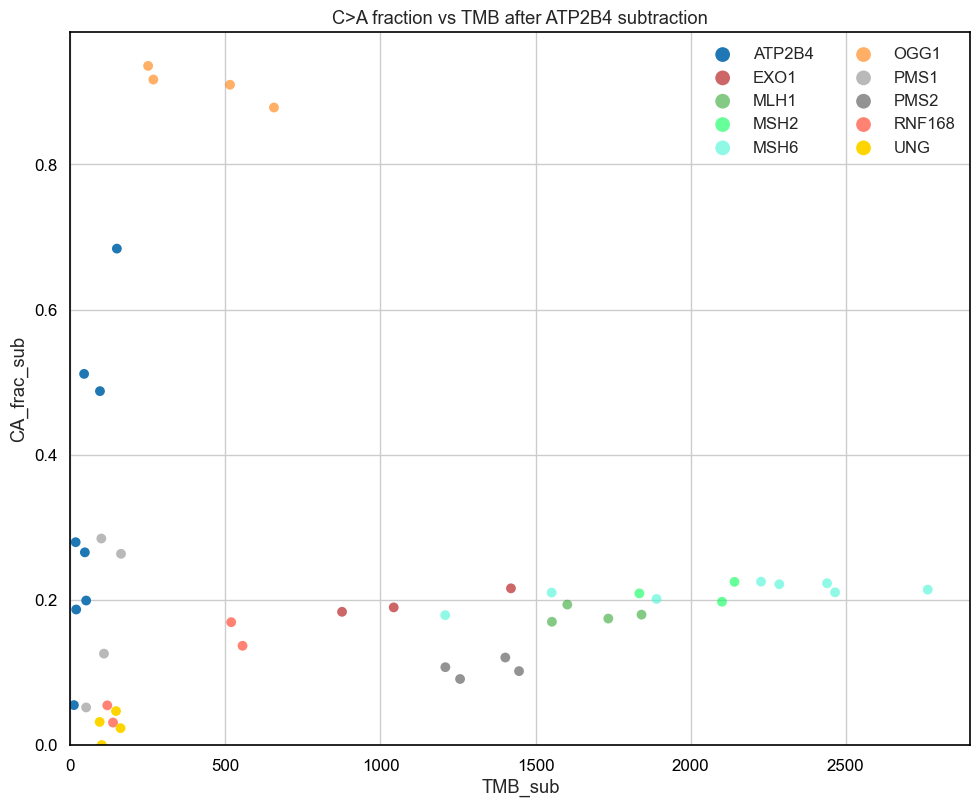

In [33]:
import numpy as np
import pandas as pd

# Assuming you already have:
# raw_df, sbs_cols, ca_cols, gene, metrics, outdir, scatter_by_gene defined

# 1) Relative profiles + absolute TMB
Xrel = raw_df[sbs_cols].astype(float).copy()
TMB  = pd.to_numeric(raw_df["Count"], errors="coerce").fillna(0.0).astype(float).values
gene = raw_df["Gene_KO"].astype(str).values

# 2) Convert to absolute counts
Xabs = Xrel.values * TMB[:, None]   # (n_rows, 96)

# 3) Background profile from ATP2B4 (mean absolute profile)
bg_mask = (gene == "ATP2B4")
if bg_mask.sum() == 0:
    raise ValueError("No ATP2B4 rows found; cannot perform ATP2B4 subtraction.")
bg_profile_abs = Xabs[bg_mask].mean(axis=0)

# 4) Subtract + clip
Xabs_sub = Xabs - bg_profile_abs[None, :]
Xabs_sub[Xabs_sub < 0] = 0.0

# 5) Recompute metrics after subtraction
TMB_sub = Xabs_sub.sum(axis=1)

# CA indices (based on sbs_cols)
ca_idx = [i for i, c in enumerate(sbs_cols) if "C>A" in c]
if len(ca_idx) == 0:
    raise ValueError("No SBS columns matched 'C>A'.")

CA_abs_sub  = Xabs_sub[:, ca_idx].sum(axis=1)
CA_frac_sub = np.divide(CA_abs_sub, np.maximum(TMB_sub, 1.0))

# 6) Store + save
metrics_sub = metrics.copy()
metrics_sub["TMB_sub"] = TMB_sub
metrics_sub["CA_abs_sub"] = CA_abs_sub
metrics_sub["CA_frac_sub"] = CA_frac_sub

metrics_sub.to_csv(outdir / "metrics_after_ATP2B4_subtraction.csv", index=False)

# Optional sanity summary
print("After subtraction:")
print(metrics_sub.loc[metrics_sub["gene"].isin(["UNG","ATP2B4"]), ["gene","TMB_sub","CA_abs_sub","CA_frac_sub"]].groupby("gene").mean())

# 7) Plot set B (inline + saved)
scatter_by_gene(
    metrics_sub, "TMB_sub", "CA_abs_sub",
    "Absolute C>A vs TMB after ATP2B4 subtraction",
    "B1_CAabs_vs_TMB_bgsub.png",
    show=True
)

scatter_by_gene(
    metrics_sub, "TMB_sub", "CA_frac_sub",
    "C>A fraction vs TMB after ATP2B4 subtraction",
    "B2_CAfrac_vs_TMB_bgsub.png",
    show=True
)


In [32]:
print(metrics_sub[["TMB_sub","CA_abs_sub","CA_frac_sub"]].dtypes)
print(metrics_sub[["TMB_sub","CA_abs_sub","CA_frac_sub"]].head())


Xabs_sub

TMB_sub        float64
CA_abs_sub     float64
CA_frac_sub    float64
dtype: object
    TMB_sub  CA_abs_sub  CA_frac_sub
0  1420.750     306.625     0.215819
1   876.000     160.750     0.183505
2  1042.625     197.625     0.189546
3   267.500     245.250     0.916822
4   250.625     234.500     0.935661


array([[32.5  , 20.5  , 10.25 , ...,  4.625, 11.75 , 11.875],
       [11.5  , 17.5  ,  8.25 , ...,  1.625,  3.75 , 12.875],
       [ 6.5  , 17.5  ,  5.25 , ...,  4.625,  5.75 ,  7.875],
       ...,
       [ 6.5  ,  3.5  ,  0.25 , ...,  1.625,  7.75 ,  5.875],
       [ 2.5  ,  2.5  ,  0.25 , ...,  0.   ,  3.75 ,  0.875],
       [11.5  ,  3.5  ,  2.25 , ...,  2.625,  3.75 ,  4.875]],
      shape=(46, 96))

In [35]:
import numpy as np
import pandas as pd
from pathlib import Path
import sigProfilerPlotting as plot

# Assumes these exist from your integrated block:
# Xabs, Xabs_sub, gene, sbs_cols, outdir

sig_out = Path(outdir) / "sigprofiler_gene_avg"
txt_raw_dir  = sig_out / "txt_raw"
txt_sub_dir  = sig_out / "txt_bgsub"
plot_raw_dir = sig_out / "plots_raw"
plot_sub_dir = sig_out / "plots_bgsub"
for d in [txt_raw_dir, txt_sub_dir, plot_raw_dir, plot_sub_dir]:
    d.mkdir(parents=True, exist_ok=True)

# ✅ recommended: SigProfilerPlotting output paths should end with "/"
plot_raw_dir_str = str(plot_raw_dir) + "/"
plot_sub_dir_str = str(plot_sub_dir) + "/"

contexts = np.array(sbs_cols, dtype=str)

def write_sigprofiler_sbs96_txt(path, contexts, values, colname="S1"):
    df = pd.DataFrame({"MutationType": contexts, colname: values})
    df.to_csv(path, sep="\t", index=False)

def avg_profile(X, gene_vec, gene_name, normalize=True):
    idx = (gene_vec == gene_name)
    if idx.sum() == 0:
        return None
    v = X[idx].mean(axis=0)
    if normalize:
        s = v.sum()
        if s > 0:
            v = v / s
    return v

genes_to_plot = sorted(pd.unique(gene))

for g in genes_to_plot:
    v_raw = avg_profile(Xabs, gene, g, normalize=True)
    v_sub = avg_profile(Xabs_sub, gene, g, normalize=True)

    if v_raw is None:
        continue

    g_safe = g.replace("/", "_")

    # --- RAW ---
    txt_raw = txt_raw_dir / f"SBS96_avgRAW_{g_safe}.txt"
    write_sigprofiler_sbs96_txt(txt_raw, contexts, v_raw, colname="S1")
    plot.plotSBS(str(txt_raw), plot_raw_dir_str, f"avgRAW_{g_safe}", "96", True)  # ✅ "96"

    # --- BG-subtracted ---
    if v_sub is not None:
        txt_sub = txt_sub_dir / f"SBS96_avgBGsub_{g_safe}.txt"
        write_sigprofiler_sbs96_txt(txt_sub, contexts, v_sub, colname="S1")
        plot.plotSBS(str(txt_sub), plot_sub_dir_str, f"avgBGsub_{g_safe}", "96", True)  # ✅ "96"

print("Saved SigProfilerPlotting outputs to:", sig_out)
print("RAW plots:", plot_raw_dir)
print("BG-sub plots:", plot_sub_dir)


Saved SigProfilerPlotting outputs to: /Users/sande/Projects/SNMF/analysis/ung_background_plots/sigprofiler_gene_avg
RAW plots: /Users/sande/Projects/SNMF/analysis/ung_background_plots/sigprofiler_gene_avg/plots_raw
BG-sub plots: /Users/sande/Projects/SNMF/analysis/ung_background_plots/sigprofiler_gene_avg/plots_bgsub


## Bootstrap 'background removed'-Samples

In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys, os, importlib

# --- Add project src to path for import ---
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from src.processing import bootstrapping as boot
importlib.reload(boot)

# --- Constants ---
N_train = 100
N_test = 1000
ds = 100
n_splits = 10
n_folds = 3
fixed_class_order = ["Control", "MMR", "HR", "BER"]

# --- Get project root dynamically ---
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# ---------------------------------------------------------------------
# Load dataset (original) + build BG-subtracted counts dataframe
# ---------------------------------------------------------------------
data_path = project_root / "data" / "raw" / "zou2021" / "zou_96SBS_filtered.pkl"
print("Loading:", data_path)
df = pd.read_pickle(data_path)
print("Shape:", df.shape)

# Identify SBS96 columns (already wide)
meta_cols = {"Gene_KO", "Protein_KO", "Subpathway_KO", "Count"}
sbs_cols = [c for c in df.columns if c not in meta_cols and isinstance(c, str) and ("[" in c and "]" in c)]
assert len(sbs_cols) >= 96, f"Expected SBS96 columns; found {len(sbs_cols)}"

# df[sbs_cols] are relative profiles; df["Count"] is absolute mutation count (TMB)
Xrel = df[sbs_cols].astype(float).copy()
TMB  = pd.to_numeric(df["Count"], errors="coerce").fillna(0.0).astype(float).values
gene = df["Gene_KO"].astype(str).values

# absolute counts
Xabs = Xrel.values * TMB[:, None]

# mean ATP2B4 absolute profile
bg_mask = (gene == "ATP2B4")
if bg_mask.sum() == 0:
    raise ValueError("No ATP2B4 rows found; cannot compute BG profile.")
bg_profile_abs = Xabs[bg_mask].mean(axis=0)

# subtract + clip
Xabs_sub = Xabs - bg_profile_abs[None, :]
Xabs_sub[Xabs_sub < 0] = 0.0

# new TMB after subtraction (row sum)
TMB_sub = Xabs_sub.sum(axis=1)

# Build bg-sub dataframe with SAME index + metadata
df_bgsub = df.copy()
df_bgsub.loc[:, sbs_cols] = Xabs_sub  # overwrite SBS columns with bg-sub ABSOLUTE counts
# Re-normalize to relative profiles
row_sums = df_bgsub[sbs_cols].sum(axis=1).replace(0, np.nan)
df_bgsub.loc[:, sbs_cols] = df_bgsub[sbs_cols].div(row_sums, axis=0).fillna(0.0)

df_bgsub["Count"] = TMB_sub          # overwrite Count to reflect post-subtraction total

print("BG-sub sanity:")
print("  original mean Count:", float(np.mean(TMB)))
print("  bg-sub   mean Count:", float(np.mean(TMB_sub)))

# ---------------------------------------------------------------------
# Map Gene_KO → Pathway class (same as before)
# ---------------------------------------------------------------------
gene_to_pathway = {
    "ATP2B4": "Control",
    "MSH2": "MMR", "MSH6": "MMR", "MLH1": "MMR", "PMS1": "MMR", "PMS2": "MMR",
    "EXO1": "HR", "RNF168": "HR",
    "UNG": "BER", "OGG1": "BER",
}
df_bgsub["label_name"] = df_bgsub["Gene_KO"].map(gene_to_pathway)
if df_bgsub["label_name"].isnull().any():
    missing = df_bgsub[df_bgsub["label_name"].isnull()]["Gene_KO"].unique()
    raise ValueError(f"Unmapped genes: {missing}")

label_map = {name: i for i, name in enumerate(fixed_class_order)}
df_bgsub["label"] = df_bgsub["label_name"].map(label_map)
df_bgsub["Gene_KO_paired"] = df_bgsub["Gene_KO"].astype(str)

print("Label distribution:")
print(df_bgsub["label_name"].value_counts())

# --- Output folder (BG-sub) ---
out_root = project_root / "data" / "processed" / "zou2021" / "splits_bg_sub"
out_root.mkdir(parents=True, exist_ok=True)

# Optional: store the full bg-sub dataset once for provenance/debugging
df_bgsub.to_pickle(out_root / "zou_96SBS_bgsub_counts.pkl")

# --- Helper ---
def save_bootstrapped_split(Xboot, suffix, outdir, prefix="D"):
    path_X = os.path.join(outdir, f"Xboot{prefix}_{suffix}.txt")
    path_Y = os.path.join(outdir, f"Yboot{prefix}_{suffix}.txt")

    mut_cols = Xboot.columns[:96]  # assumes SBS96 are first 96 columns (true for your boot output)
    Xboot[mut_cols].T.to_csv(path_X, sep="\t")

    y_onehot = pd.get_dummies(Xboot["label_name"]).T
    y_onehot = y_onehot.reindex(fixed_class_order, fill_value=0)
    y_onehot.columns = Xboot.index
    y_onehot.to_csv(path_Y, sep="\t")

# ---------------------------------------------------------------------
# Generate new splits (on BG-sub data)
# ---------------------------------------------------------------------
for split_id in range(n_splits):
    rng = np.random.default_rng(42 + split_id)

    # --- Gene-wise balanced test selection ---
    te_idx, tr_idx = [], []
    for g, subdf in df_bgsub.groupby("Gene_KO"):
        n_remove = 2 if g == "ATP2B4" else 1
        n_remove = min(n_remove, len(subdf) - 1)
        test_samples = rng.choice(subdf.index, size=n_remove, replace=False)
        train_samples = subdf.index.difference(test_samples)
        te_idx.extend(test_samples)
        tr_idx.extend(train_samples)

    df_test = df_bgsub.loc[te_idx]
    df_train = df_bgsub.loc[tr_idx]

    split_dir = out_root / f"split_{split_id:02d}"
    split_dir.mkdir(parents=True, exist_ok=True)
    df_train.to_pickle(split_dir / "train.pkl")
    df_test.to_pickle(split_dir / "test.pkl")

    print(f"\nSplit {split_id:02d}: train={len(df_train)} | test={len(df_test)}")

    # -----------------------------------------------------------------
    # Split train into 3 folds (gene-balanced + randomized remainder)
    # -----------------------------------------------------------------
    folds = {i: [] for i in range(n_folds)}
    for g, subdf in df_train.groupby("Gene_KO"):
        samples = subdf.index.to_list()
        rng.shuffle(samples)

        base, rem = divmod(len(samples), n_folds)
        fold_sizes = [base] * n_folds
        if rem > 0:
            for i in rng.choice(n_folds, size=rem, replace=False):
                fold_sizes[i] += 1

        start = 0
        for f, size in enumerate(fold_sizes):
            end = start + size
            folds[f].extend(samples[start:end])
            start = end

    subfolds_dir = split_dir / "sub_folds"
    subfolds_dir.mkdir(exist_ok=True)

    XbootM_all, XbootD_all = [], []

    # -----------------------------------------------------------------
    # Bootstrap each fold and combine
    # -----------------------------------------------------------------
    for i in range(n_folds):
        fold_idx = folds[i]
        fold_df = df_train.loc[fold_idx]
        fold_dir = subfolds_dir / f"fold_{i+1}"
        fold_dir.mkdir(parents=True, exist_ok=True)

        print(f"→ Bootstrapping BG-sub split {split_id:02d}, fold {i+1} ({len(fold_df)} samples)")

        XbootM_train, XbootD_train = boot.bootstrap_dirichlet(
            fold_df, L=N_train, dirichlet_strength=ds, suffix=f"train_fold{i+1}", class_col="label"
        )

        save_bootstrapped_split(XbootM_train, f"train_fold{i+1}", fold_dir, prefix="M")
        save_bootstrapped_split(XbootD_train, f"train_fold{i+1}", fold_dir, prefix="D")

        XbootM_all.append(XbootM_train)
        XbootD_all.append(XbootD_train)

    # -----------------------------------------------------------------
    # Combine folds into train_all
    # -----------------------------------------------------------------
    XbootM_all = pd.concat(XbootM_all, axis=0)
    XbootD_all = pd.concat(XbootD_all, axis=0)

    save_bootstrapped_split(XbootM_all, "train_all", split_dir, prefix="M")
    save_bootstrapped_split(XbootD_all, "train_all", split_dir, prefix="D")

    # -----------------------------------------------------------------
    # Bootstrap the small test set
    # -----------------------------------------------------------------
    print(f"→ Bootstrapping BG-sub test ({len(df_test)} samples → {N_test})...")
    XbootM_test, XbootD_test = boot.bootstrap_dirichlet(
        df_test, L=N_test, dirichlet_strength=ds, suffix="test", class_col="label"
    )

    save_bootstrapped_split(XbootM_test, "test", split_dir, prefix="M")
    save_bootstrapped_split(XbootD_test, "test", split_dir, prefix="D")

    print(f"✅ Saved BG-sub split_{split_id:02d}: train={len(df_train)} | test={len(df_test)}")

print(f"\n✅ Done. BG-sub bootstrapped splits saved under:\n{out_root}")


Loading: /Users/sande/Projects/SNMF/data/raw/zou2021/zou_96SBS_filtered.pkl
Shape: (46, 100)
BG-sub sanity:
  original mean Count: 1121.0869565217392
  bg-sub   mean Count: 927.7853260869565
Label distribution:
label_name
MMR        23
BER         8
Control     8
HR          7
Name: count, dtype: int64

Split 00: train=35 | test=11
→ Bootstrapping BG-sub split 00, fold 1 (12 samples)
→ Bootstrapping BG-sub split 00, fold 2 (11 samples)
→ Bootstrapping BG-sub split 00, fold 3 (12 samples)
→ Bootstrapping BG-sub test (11 samples → 1000)...
✅ Saved BG-sub split_00: train=35 | test=11

Split 01: train=35 | test=11
→ Bootstrapping BG-sub split 01, fold 1 (11 samples)
→ Bootstrapping BG-sub split 01, fold 2 (11 samples)
→ Bootstrapping BG-sub split 01, fold 3 (13 samples)
→ Bootstrapping BG-sub test (11 samples → 1000)...
✅ Saved BG-sub split_01: train=35 | test=11

Split 02: train=35 | test=11
→ Bootstrapping BG-sub split 02, fold 1 (11 samples)
→ Bootstrapping BG-sub split 02, fold 2 (12 s

In [40]:
# after XbootD_train is created
mut_cols = XbootD_train.columns[:96]
print("Row sum stats (first 5):", XbootD_train[mut_cols].sum(axis=1).head().tolist())
print("Mean row sum:", float(XbootD_train[mut_cols].sum(axis=1).mean()))
print("Example original Count mean:", float(fold_df["Count"].mean()))


Row sum stats (first 5): [1.0, 1.0000000000000004, 1.0000000000000002, 1.0, 1.0000000000000002]
Mean row sum: 1.0
Example original Count mean: 842.7916666666666


## SNMF with Lc = 0.1 and Lc = 0.0 on 'background removed'-Samples

In [41]:
import os
import pandas as pd
import numpy as np
import importlib
import matplotlib.pyplot as plt
import SNMF.sigpro as sig

# ensure fresh reload
sig = importlib.reload(sig)
import SNMF.subroutines, SNMF.nmf_cpu
importlib.reload(SNMF.subroutines)
importlib.reload(SNMF.nmf_cpu)

# --- Parameters ---
min_k = max_k = 5
reps = 10
lr = 5e-3
l_p = 0.0001
lc_values = [0.0, 0.1]                
bootstrap_types = ["multinomial"] 

n_splits = 10 
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# ✅ BG-sub splits
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_bg_sub")

# ✅ new output folder
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_bgsub_lc_compact")
os.makedirs(results_root, exist_ok=True)

all_results = []

for bootstrap in bootstrap_types:
    prefix = "M" if bootstrap == "multinomial" else "D"

    for l_c in lc_values:
        l_c_str = f"{l_c:.1f}".replace(".", "")
        base_output_path = os.path.join(results_root, f"SNMF_results_{bootstrap}_lc{l_c_str}")
        os.makedirs(base_output_path, exist_ok=True)

        print(f"\n=== Running SNMF on BG-sub ({bootstrap.upper()} bootstrap, λc={l_c}) ===")

        for split_id in range(n_splits):
            split_dir = os.path.join(data_root, f"split_{split_id:02d}")
            if not os.path.exists(split_dir):
                print(f"Skipping missing {split_dir}")
                continue

            path_X_train = os.path.join(split_dir, f"Xboot{prefix}_train_all.txt")
            path_Y_train = os.path.join(split_dir, f"Yboot{prefix}_train_all.txt")
            path_X_test  = os.path.join(split_dir, f"Xboot{prefix}_test.txt")
            path_Y_test  = os.path.join(split_dir, f"Yboot{prefix}_test.txt")

            output_path = os.path.join(base_output_path, f"split_{split_id:02d}")
            os.makedirs(output_path, exist_ok=True)

            # --- Train ---
            train_out = sig.sigProfilerExtractor(
                input_type="text",
                output=output_path,
                input_data=path_X_train,
                input_label=path_Y_train,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                seeds="random",
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                make_decomposition_plots=False
            )

            # --- Test ---
            test_out = sig.test_sigProfilerExtractor(
                input_type="text",
                model_path=output_path,
                output=output_path,
                test_data=path_X_test,
                test_label=path_Y_test,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                filter=False,
                make_decomposition_plots=False
            )

            # --- Normalize outputs ---
            if isinstance(train_out, pd.DataFrame):
                row_train = train_out.iloc[0].to_dict()
            elif isinstance(train_out, dict):
                row_train = train_out
            else:
                raise ValueError("train_out must be a dict or DataFrame")

            if isinstance(test_out, (list, tuple)):
                acc_test, f1_test, rec_test = test_out
            elif isinstance(test_out, dict):
                acc_test = test_out.get("acc_test", np.nan)
                f1_test  = test_out.get("f1_test", np.nan)
                rec_test = test_out.get("rec_test", np.nan)
            elif isinstance(test_out, pd.DataFrame):
                acc_test = test_out.loc[0, "acc_test"]
                f1_test  = test_out.loc[0, "f1_test"]
                rec_test = test_out.loc[0, "rec_test"]
            else:
                raise ValueError("test_out must be list/dict/DataFrame")

            all_results.append({
                "split": split_id,
                "bootstrap": bootstrap,
                "lambda_c": l_c,
                "accuracy_test": acc_test,
                "f1_test": f1_test,
                "recall_test": rec_test,
                "Lrec_train": row_train.get("Lrec_mean", np.nan),
                "Lce_train": row_train.get("Lce_mean", np.nan),
                "Ltot_train": row_train.get("Ltot_mean", np.nan),
                "stability": row_train.get("stability_mean_refit0", np.nan),
                "epochs_mean": row_train.get("epochs_mean", np.nan),
                "k": min_k,
                "lr": lr,
                "lambda_p": l_p,
                "reps": reps
            })

            print(f" split {split_id:02d} λc={l_c}: acc={acc_test:.3f}, f1={f1_test:.3f}, rec={rec_test:.3f}")

# --- Save results once ---
results_df = pd.DataFrame(all_results)
final_results_path = os.path.join(results_root, "SNMF_BGsub_multinomial_lc00_vs_lc01.csv")
results_df.to_csv(final_results_path, index=False)
print(f"\nSaved results → {final_results_path}")

# --------------------------------------------------------------------
# Boxplots over splits: λc=0.0 vs 0.1
# --------------------------------------------------------------------
def boxplot_metric(metric, ylabel):
    df0 = results_df[results_df["lambda_c"] == 0.0][metric].dropna().values
    df1 = results_df[results_df["lambda_c"] == 0.1][metric].dropna().values

    plt.figure(figsize=(5,4))
    plt.boxplot([df0, df1], labels=["lc=0.0", "lc=0.1"], showfliers=False)
    plt.ylabel(ylabel)
    plt.title(f"BG-sub: {metric} across {n_splits} splits")
    plt.tight_layout()
    out_png = os.path.join(results_root, f"boxplot_{metric}_lc00_vs_lc01.png")
    plt.savefig(out_png, dpi=200)
    plt.show()
    print("Saved:", out_png)

boxplot_metric("accuracy_test", "Accuracy (test)")
boxplot_metric("f1_test", "F1 (test)")
boxplot_metric("recall_test", "Recall (test)")
boxplot_metric("stability", "Signature stability")



=== Running SNMF on BG-sub (MULTINOMIAL bootstrap, λc=0.0) ===

************** Reported Current Memory Use: 0.46 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.257
Epoch: 0 ; Ltot = 1.00 ;  Lrec = 1.00 ; Lce = 1.39 ; acc = 0.272
Epoch: 0 ; Ltot = 1.00 ;  Lrec = 1.00 ; Lce = 1.39 ; acc = 0.238
Epoch: 0 ; Ltot = 1.00 ;  Lrec = 1.00 ; Lce = 1.39 ; acc = 0.272
Epoch: 0 ; Ltot = 1.00 ;  Lrec = 1.00 ; Lce = 1.39 ; acc = 0.230
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.243
Epoch: 0 ; Ltot = 1.00 ;  Lrec = 1.00 ; Lce = 1.39 ; acc = 0.228
Epoch: 100 ; Ltot = 0.51 ;  Lrec = 0.51 ; Lce = 0.40 ; acc = 0.929
Epoch: 100 ; Ltot = 0.52 ;  Lrec = 0.52 ; Lce = 0.52 ; acc = 0.765
Epoch: 100 ; Ltot = 0.53 ;  Lrec = 0.53 ; Lce = 0.50 ; acc = 0.835
Epoch: 100 ; Ltot = 0.51 ;  Lrec = 0.51 ; Lce = 0.47 ; acc = 0.754
Epoch: 100 ; Ltot = 0.53 ;  Lrec = 0.53 ; Lce = 0.53 ; ac

/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/4198248995.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/4198248995.py:63: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


Wilcoxon (λc=0.1 > λc=0.0) on accuracy_test: p=0.188 (ns), n_pairs=10
Saved: /Users/sande/Projects/SNMF/results/figures/sup/ung_bgsub/boxplot_accuracy_test_bgsub_lc00_vs_lc01_splits0-9.pdf


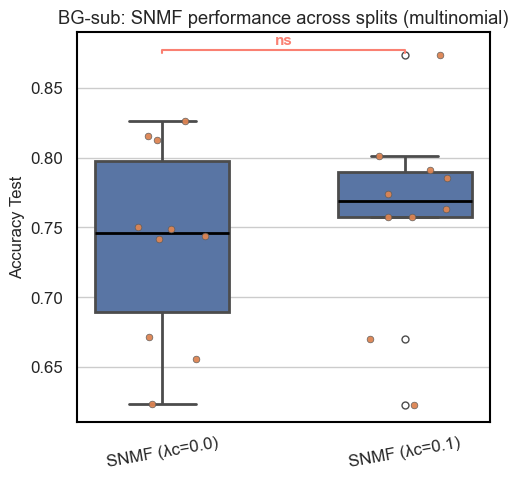

               median   mean    std  count
method                                    
SNMF (λc=0.0)   0.746  0.739  0.070     10
SNMF (λc=0.1)   0.769  0.760  0.069     10


/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/4198248995.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)


In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

sns.set(style="whitegrid", font_scale=1.1)
%matplotlib inline

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_bgsub_lc_compact")  # <- adjust if needed
fig_dir = os.path.join(project_root, "results", "figures", "sup", "ung_bgsub")
os.makedirs(fig_dir, exist_ok=True)

# ---- load (your runner saved a single combined csv) ----
csv_path = os.path.join(results_root, "SNMF_BGsub_multinomial_lc00_vs_lc01.csv")
df = pd.read_csv(csv_path)

# ---- keep only splits 0-9 (exclude 10) ----
if "split" in df.columns:
    df = df[df["split"].isin(range(10))].copy()

# ---- keep only lc 0.0 and 0.1 ----
df = df[df["lambda_c"].isin([0.0, 0.1])].copy()
df["method"] = df["lambda_c"].map({0.0: "SNMF (λc=0.0)", 0.1: "SNMF (λc=0.1)"})
order = ["SNMF (λc=0.0)", "SNMF (λc=0.1)"]
df["method"] = pd.Categorical(df["method"], categories=order, ordered=True)

metric = "accuracy_test"   # or f1_test, recall_test, stability
metric = "accuracy_test"   # or f1_test, recall_test, stability

# ---- paired Wilcoxon across splits ----
p, sig = np.nan, "na"
n_pairs = 0
if "split" in df.columns:
    wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
    wide = wide.dropna()
    if wide.shape[0] >= 2:
        a = wide["SNMF (λc=0.1)"].to_numpy()
        b = wide["SNMF (λc=0.0)"].to_numpy()
        n_pairs = len(a)
        try:
            _, p = wilcoxon(a, b, alternative="greater", zero_method="wilcox")
        except ValueError:
            p = np.nan
        sig = "***" if (p == p and p < 0.001) else "**" if (p == p and p < 0.01) else "*" if (p == p and p < 0.05) else "ns"

print(f"Wilcoxon (λc=0.1 > λc=0.0) on {metric}: p={p:.3g} ({sig}), n_pairs={n_pairs}" if p==p else f"Wilcoxon: p=NA, n_pairs={n_pairs}")

# ---- plot ----
fig, ax = plt.subplots(figsize=(5.2, 5.0))

sns.boxplot(
    data=df, x="method", y=metric, order=order,
    width=0.55, showfliers=True,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="black"),
    flierprops=dict(marker="o", markersize=5, linestyle="none"),
    ax=ax
)
sns.stripplot(
    data=df, x="method", y=metric, order=order,
    jitter=0.18, size=4.8, alpha=0.95,
    linewidth=0.5, edgecolor="gray",
    ax=ax
)

# ---- bracket with significance ----
ymax = np.nanmax(df[metric].values)
y = ymax + 0.01 * (1.0 - ymax)  # small headroom
dy = 0.008
ax.plot([0, 0, 1, 1], [y, y + dy/3, y + dy/3, y], lw=1.5, c="salmon", clip_on=False)
ax.text(0.5, y + dy/2, sig, ha="center", va="bottom",
        color="salmon", fontsize=11, fontweight="bold", clip_on=False)

# ---- style ----
ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12)
ax.set_xlabel("")
ax.set_title("BG-sub: SNMF performance across splits (multinomial)")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

# set limits if you want (same vibe as before)
# ax.set_ylim(0.8, 1.0)

plt.xticks(rotation=10)
plt.tight_layout()

out_pdf = os.path.join(fig_dir, f"boxplot_{metric}_bgsub_lc00_vs_lc01_splits0-9.pdf")
plt.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print("Saved:", out_pdf)
plt.show()

# ---- summary ----
summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)
print(summary)


In [5]:
df.columns

Index(['split', 'bootstrap', 'lambda_c', 'accuracy_test', 'f1_test',
       'recall_test', 'Lrec_train', 'Lce_train', 'Ltot_train', 'stability',
       'epochs_mean', 'k', 'lr', 'lambda_p', 'reps', 'method'],
      dtype='object')

accuracy_test: p=0.188 (ns), n_pairs=10
Saved: /Users/sande/Projects/SNMF/results/figures/sup/ung_bgsub/boxplot_accuracy_test_bgsub_lc00_vs_lc01_splits0-9.pdf


/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:78: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


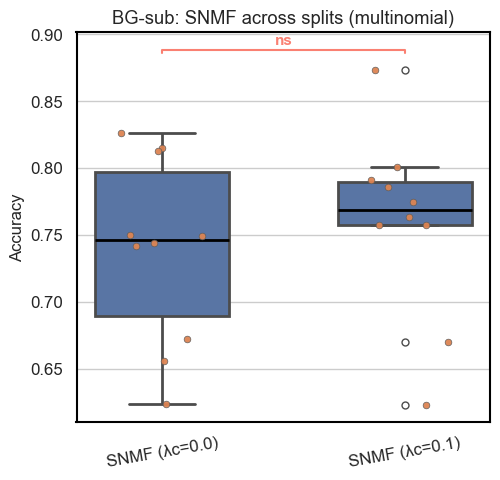

/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:78: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.strip

               median   mean    std  count
method                                    
SNMF (λc=0.0)   0.746  0.739  0.070     10
SNMF (λc=0.1)   0.769  0.760  0.069     10


f1_test: p=0.0967 (ns), n_pairs=10
Saved: /Users/sande/Projects/SNMF/results/figures/sup/ung_bgsub/boxplot_f1_test_bgsub_lc00_vs_lc01_splits0-9.pdf


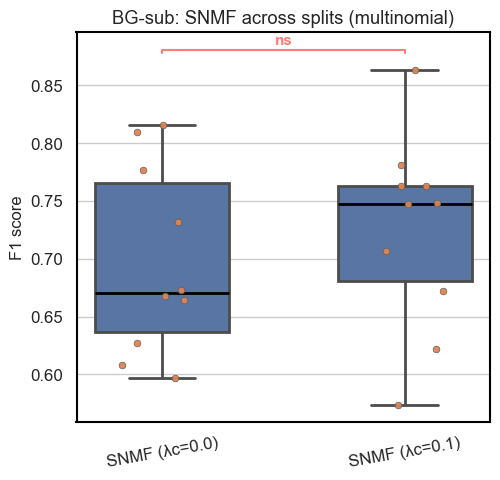

/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:78: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.strip

               median   mean    std  count
method                                    
SNMF (λc=0.0)   0.671  0.697  0.081     10
SNMF (λc=0.1)   0.748  0.724  0.083     10


recall_test: p=0.976 (ns), n_pairs=10
Saved: /Users/sande/Projects/SNMF/results/figures/sup/ung_bgsub/boxplot_recall_test_bgsub_lc00_vs_lc01_splits0-9.pdf


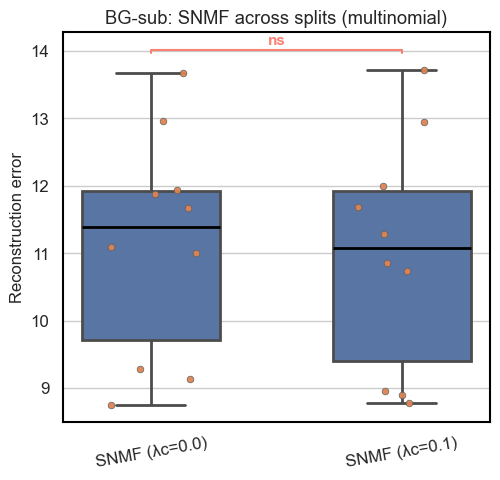

               median    mean    std  count
method                                     
SNMF (λc=0.0)  11.383  11.136  1.645     10
SNMF (λc=0.1)  11.070  10.983  1.713     10


stability: p=0.994 (ns), n_pairs=10


/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:78: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.strip

Saved: /Users/sande/Projects/SNMF/results/figures/sup/ung_bgsub/boxplot_stability_bgsub_lc00_vs_lc01_splits0-9.pdf


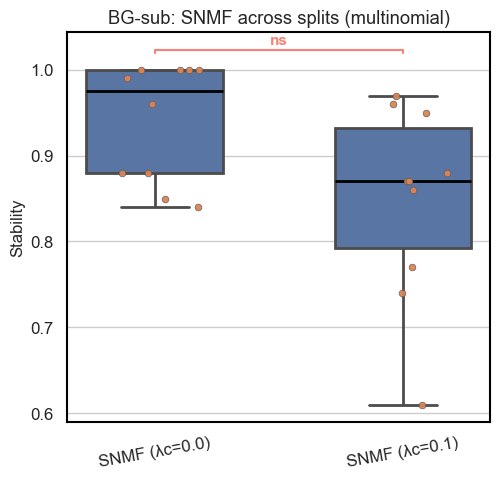

/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:78: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.strip

               median   mean    std  count
method                                    
SNMF (λc=0.0)   0.975  0.940  0.069     10
SNMF (λc=0.1)   0.870  0.848  0.113     10


Lrec_train: p=1 (ns), n_pairs=10
Saved: /Users/sande/Projects/SNMF/results/figures/sup/ung_bgsub/boxplot_Lrec_train_bgsub_lc00_vs_lc01_splits0-9.pdf


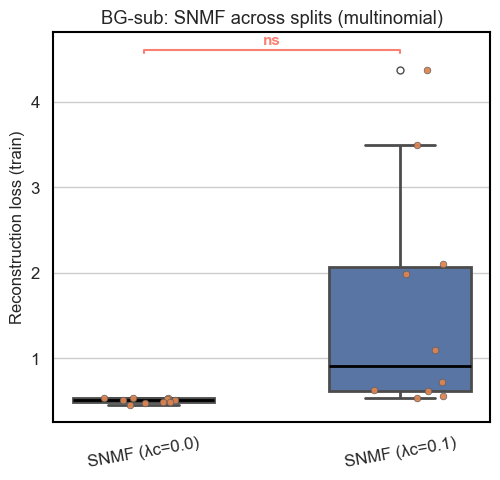

               median   mean    std  count
method                                    
SNMF (λc=0.0)   0.511  0.509  0.027     10
SNMF (λc=0.1)   0.912  1.612  1.366     10




/var/folders/jn/w0qr5f194bl8ks3rjxbcvm140000gn/T/ipykernel_52861/596593000.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)


In [8]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

sns.set(style="whitegrid", font_scale=1.1)
%matplotlib inline

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_bgsub_lc_compact")
fig_dir = os.path.join(project_root, "results", "figures", "sup", "ung_bgsub")
os.makedirs(fig_dir, exist_ok=True)

# ---- load ----
csv_path = os.path.join(results_root, "SNMF_BGsub_multinomial_lc00_vs_lc01.csv")
df = pd.read_csv(csv_path)

# ---- keep splits 0–9 ----
if "split" in df.columns:
    df = df[df["split"].isin(range(10))].copy()

# ---- keep λc 0.0 and 0.1 ----
df = df[df["lambda_c"].isin([0.0, 0.1])].copy()
df["method"] = df["lambda_c"].map({0.0: "SNMF (λc=0.0)", 0.1: "SNMF (λc=0.1)"})
order = ["SNMF (λc=0.0)", "SNMF (λc=0.1)"]
df["method"] = pd.Categorical(df["method"], categories=order, ordered=True)

# ---- metrics to plot ----
metrics = [
    ("accuracy_test", "Accuracy", "greater"),
    ("f1_test", "F1 score", "greater"),
    ("recall_test", "Reconstruction error", "greater"),  # renamed only in label
    ("stability", "Stability", "greater"),
    ("Lrec_train", "Reconstruction loss (train)", "less")  # lower is better
]

for metric, ylabel, direction in metrics:

    # ---- paired Wilcoxon ----
    p, sig = np.nan, "na"
    n_pairs = 0

    wide = df.pivot_table(index="split", columns="method", values=metric, aggfunc="mean")
    wide = wide.dropna()

    if wide.shape[0] >= 2:
        a = wide["SNMF (λc=0.1)"].to_numpy()
        b = wide["SNMF (λc=0.0)"].to_numpy()
        n_pairs = len(a)

        try:
            _, p = wilcoxon(a, b, alternative=direction, zero_method="wilcox")
        except ValueError:
            p = np.nan

        sig = "***" if (p == p and p < 0.001) else \
              "**"  if (p == p and p < 0.01)  else \
              "*"   if (p == p and p < 0.05)  else "ns"

    print(f"{metric}: p={p:.3g} ({sig}), n_pairs={n_pairs}" if p==p else f"{metric}: p=NA")

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(5.2, 5.0))

    sns.boxplot(
        data=df, x="method", y=metric, order=order,
        width=0.55, showfliers=True,
        boxprops=dict(linewidth=2),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        medianprops=dict(linewidth=2, color="black"),
        flierprops=dict(marker="o", markersize=5, linestyle="none"),
        ax=ax
    )

    sns.stripplot(
        data=df, x="method", y=metric, order=order,
        jitter=0.18, size=4.8, alpha=0.95,
        linewidth=0.5, edgecolor="gray",
        ax=ax
    )

    # ---- significance bracket ----
    ymax = np.nanmax(df[metric].values)
    ymin = np.nanmin(df[metric].values)
    y = ymax + 0.05 * (ymax - ymin)
    dy = 0.03 * (ymax - ymin)

    ax.plot([0, 0, 1, 1], [y, y+dy/3, y+dy/3, y], lw=1.5, c="salmon", clip_on=False)
    ax.text(0.5, y + dy/2, sig, ha="center", va="bottom",
            color="salmon", fontsize=11, fontweight="bold", clip_on=False)

    # ---- style ----
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("")
    ax.set_title("BG-sub: SNMF across splits (multinomial)")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

    plt.xticks(rotation=10)
    plt.tight_layout()

    out_pdf = os.path.join(fig_dir, f"boxplot_{metric}_bgsub_lc00_vs_lc01_splits0-9.pdf")
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
    print("Saved:", out_pdf)

    plt.show()

    # ---- summary ----
    summary = df.groupby("method")[metric].agg(["median","mean","std","count"]).round(3)
    print(summary)
    print("\n")


# SNMF - relative check effect new... 

In [51]:
import os
import pandas as pd
import numpy as np
import importlib
import SNMF.sigpro as sig

# ensure fresh reload
sig = importlib.reload(sig)
import importlib, SNMF.subroutines
import SNMF.nmf_cpu
importlib.reload(SNMF.subroutines)
importlib.reload(SNMF.nmf_cpu)


# --- Parameters ---
min_k = max_k = 5
reps = 10
lr = 5e-3
l_p = 0.0001
lc_values = [0.1]

# lc_values = [0.0, 0.1, 100]
# bootstrap_types = ["multinomial", "dirichlet"]
bootstrap_types = ["multinomial"]

N_train, N_test = 100, 1000
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new4_temp")
os.makedirs(results_root, exist_ok=True)

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = "M" if bootstrap == "multinomial" else "D"

    for l_c in lc_values:
        l_c_str = f"{l_c:.1f}".replace(".", "")
        base_output_path = os.path.join(results_root, f"SNMF_results_{bootstrap}_lc{l_c_str}")
        os.makedirs(base_output_path, exist_ok=True)

        results_df = pd.DataFrame()

        print(f"\n=== Running SNMF ({bootstrap.upper()} bootstrap, λc={l_c}) ===")

        # 🔹 Run over all 11 splits (00–10)
        # for split_id in range(11):
        for split_id in range(2):
            split_dir = os.path.join(data_root, f"split_{split_id:02d}")
            if not os.path.exists(split_dir):
                print(f"Skipping missing {split_dir}")
                continue

            print(f"\n--- Split {split_id:02d} ---")


            path_X_train = os.path.join(split_dir, f"Xboot{prefix}_train_all.txt")
            path_Y_train = os.path.join(split_dir, f"Yboot{prefix}_train_all.txt")
            path_X_test = os.path.join(split_dir, f"Xboot{prefix}_test.txt")
            path_Y_test = os.path.join(split_dir, f"Yboot{prefix}_test.txt")

            output_path = os.path.join(base_output_path, f"split_{split_id:02d}")
            os.makedirs(output_path, exist_ok=True)

            # --- Train SNMF ---
            print(f"→ Training SNMF on split {split_id:02d}")
            train_out = sig.sigProfilerExtractor(
                input_type="text",
                output=output_path,
                input_data=path_X_train,
                input_label=path_Y_train,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                seeds="random",
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                make_decomposition_plots=False
            )

            # --- Test SNMF ---
            print(f"→ Evaluating SNMF on split {split_id:02d}")
            test_out = sig.test_sigProfilerExtractor(
                input_type="text",
                model_path=output_path,
                output=output_path,
                test_data=path_X_test,
                test_label=path_Y_test,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                filter=False,
                make_decomposition_plots=False
            )

            # --- Handle structured outputs ---
            if isinstance(train_out, pd.DataFrame):
                row_train = train_out.iloc[0].to_dict()
            elif isinstance(train_out, dict):
                row_train = train_out
            else:
                raise ValueError("train_out must be a dict or DataFrame")

            if isinstance(test_out, (list, tuple)):
                acc_test, f1_test, rec_test = test_out
            elif isinstance(test_out, dict):
                acc_test = test_out.get("acc_test", np.nan)
                f1_test = test_out.get("f1_test", np.nan)
                rec_test = test_out.get("rec_test", np.nan)
            elif isinstance(test_out, pd.DataFrame):
                acc_test = test_out.loc[0, "acc_test"]
                f1_test = test_out.loc[0, "f1_test"]
                rec_test = test_out.loc[0, "rec_test"]
            else:
                raise ValueError("test_out must be list/dict/DataFrame")

            # --- Aggregate results ---
            df_comb = pd.DataFrame([{
                "split": split_id,
                "bootstrap": bootstrap,
                "lambda_c": l_c,
                "accuracy_test": acc_test,
                "f1_test": f1_test,
                "recall_test": rec_test,
                "Lrec_train": row_train.get("Lrec_mean", np.nan),
                "Lce_train": row_train.get("Lce_mean", np.nan),
                "Ltot_train": row_train.get("Ltot_mean", np.nan),
                "stability": row_train.get("stability_mean_refit0", np.nan),
                "n_filter": row_train.get("n_filter", np.nan),
                "epochs_mean": row_train.get("epochs_mean", np.nan),
                "k": min_k,
                "lr": lr,
                "lambda_p": l_p,
                "reps": reps
            }])

            results_df = pd.concat([results_df, df_comb], ignore_index=True)

            print(f" Split {split_id:02d}: acc={acc_test:.3f}, f1={f1_test:.3f}, rec={rec_test:.3f}")

        # --- Save per (bootstrap, λc) condition ---
        final_results_path = os.path.join(
            results_root, f"SNMF_{bootstrap}_lc{l_c_str}_full.csv"
        )
        results_df.to_csv(final_results_path, index=False)
        print(f"\n Saved {bootstrap} λc={l_c} results → {final_results_path}")



=== Running SNMF (MULTINOMIAL bootstrap, λc=0.1) ===

--- Split 00 ---
→ Training SNMF on split 00

************** Reported Current Memory Use: 0.13 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 1.13 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.274
Epoch: 0 ; Ltot = 1.13 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.273
Epoch: 0 ; Ltot = 1.13 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.251
Epoch: 0 ; Ltot = 1.13 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.282
Epoch: 0 ; Ltot = 1.13 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.244
Epoch: 0 ; Ltot = 1.13 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.250
[dbg fit] H_sum(mean/med/min/max)=0.0199/0.0199/0.0166/0.0225 H_mean=0.00398 |B|(mean)=0.526 ||B||F=2.64 logits[min,max]=0.00381,0.0178 pmax_mean=0.251 pred_frac=[0.  ,0.58,0.08,0.34]
[dbg fit] H_sum(mean/med/min/max)=0.019/0.0191/0.0149/0.0226 H_mean=0.0038 |B|(mean)=0.509 ||B||F=2.5 logits[min,max]=0.000528,0.0146 pmax_mean=0.251 pred_frac=[0.63,0.  

## DEBUG - Lc for Counts

In [4]:
import os
import pandas as pd
import numpy as np
import importlib
import SNMF.sigpro as sig

# ensure fresh reload
sig = importlib.reload(sig)
import SNMF.subroutines
import SNMF.nmf_cpu
importlib.reload(SNMF.subroutines)
importlib.reload(SNMF.nmf_cpu)

# --- Parameters ---
min_k = max_k = 7
reps = 10
lr = 5e-3 / 50000
l_p = 0.1

# Sweep values (include baseline 0.0)
# lc_values = [0.0, 100, 1000, 10000]
# lc_values = [10000, 1000, 100, 0.0]
# lc_values = [1, 0.1, 0 ]
lc_values = [50, 0]

bootstrap_types = ["multinomial"]

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# X from counts,  Y from original splits_new
x_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_count_keepnames")
y_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")

results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count_lc_sweep_k7")
os.makedirs(results_root, exist_ok=True)

def assert_exists(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

def lc_to_tag(lc: float) -> str:
    """
    Folder/file-safe tag for lambda_c values.
    Examples:
      0.0 -> lc0
      0.1 -> lc0p1
      1   -> lc1
      10  -> lc10
      100 -> lc100
    """
    # avoid floating artifacts
    if abs(lc - round(lc)) < 1e-12:
        return f"lc{int(round(lc))}"
    s = f"{lc}".replace(".", "p")
    return f"lc{s}"

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = "M" if bootstrap == "multinomial" else "D"

    for l_c in lc_values:
        lc_tag = lc_to_tag(l_c)
        base_output_path = os.path.join(results_root, f"SNMF_results_{bootstrap}_{lc_tag}")
        os.makedirs(base_output_path, exist_ok=True)

        results_df = pd.DataFrame()

        print(f"\n=== Running SNMF ({bootstrap.upper()} bootstrap, λc={l_c}) ===")
        print("X root:", x_root)
        print("Y root:", y_root)
        print("Output:", base_output_path)

        # Run over all 11 splits (00–10)
        # for split_id in range(10):
        for split_id in range(11):
            split_name = f"split_{split_id:02d}"
            split_dir_X = os.path.join(x_root, split_name)
            split_dir_Y = os.path.join(y_root, split_name)

            if not os.path.exists(split_dir_X):
                print(f"Skipping missing X dir {split_dir_X}")
                continue
            if not os.path.exists(split_dir_Y):
                print(f"Skipping missing Y dir {split_dir_Y}")
                continue

            print(f"\n--- {split_name} ---")

            path_X_train = os.path.join(split_dir_X, f"Xboot{prefix}_train_all.txt")
            path_X_test  = os.path.join(split_dir_X, f"Xboot{prefix}_test.txt")

            path_Y_train = os.path.join(split_dir_Y, f"Yboot{prefix}_train_all.txt")
            path_Y_test  = os.path.join(split_dir_Y, f"Yboot{prefix}_test.txt")

            for p in [path_X_train, path_X_test, path_Y_train, path_Y_test]:
                assert_exists(p)

            output_path = os.path.join(base_output_path, split_name)
            os.makedirs(output_path, exist_ok=True)

            # --- Train SNMF ---
            print(f"→ Training SNMF on {split_name}")
            train_out = sig.sigProfilerExtractor(
                input_type="text",
                output=output_path,
                input_data=path_X_train,
                input_label=path_Y_train,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                seeds="random",
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                # filter=False,
                make_decomposition_plots=False
            )

            # --- Test SNMF ---
            print(f"→ Evaluating SNMF on {split_name}")
            test_out = sig.test_sigProfilerExtractor(
                input_type="text",
                model_path=output_path,
                output=output_path,
                test_data=path_X_test,
                test_label=path_Y_test,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                filter=False,
                make_decomposition_plots=False
            )

            # --- Handle structured outputs ---
            if isinstance(train_out, pd.DataFrame):
                row_train = train_out.iloc[0].to_dict()
            elif isinstance(train_out, dict):
                row_train = train_out
            else:
                raise ValueError("train_out must be a dict or DataFrame")

            if isinstance(test_out, (list, tuple)):
                acc_test, f1_test, rec_test = test_out
            elif isinstance(test_out, dict):
                acc_test = test_out.get("acc_test", np.nan)
                f1_test  = test_out.get("f1_test", np.nan)
                rec_test = test_out.get("rec_test", np.nan)
            elif isinstance(test_out, pd.DataFrame):
                acc_test = test_out.loc[0, "acc_test"]
                f1_test  = test_out.loc[0, "f1_test"]
                rec_test = test_out.loc[0, "rec_test"]
            else:
                raise ValueError("test_out must be list/dict/DataFrame")

            df_comb = pd.DataFrame([{
                "split": split_id,
                "bootstrap": bootstrap,
                "lambda_c": l_c,
                "accuracy_test": acc_test,
                "f1_test": f1_test,
                "recall_test": rec_test,
                "Lrec_train": row_train.get("Lrec_mean", np.nan),
                "Lce_train": row_train.get("Lce_mean", np.nan),
                "Ltot_train": row_train.get("Ltot_mean", np.nan),
                "stability": row_train.get("stability_mean_refit0", np.nan),
                "n_filter": row_train.get("n_filter", np.nan),
                "epochs_mean": row_train.get("epochs_mean", np.nan),
                "k": min_k,
                "lr": lr,
                "lambda_p": l_p,
                "reps": reps
            }])

            results_df = pd.concat([results_df, df_comb], ignore_index=True)
            print(f" {split_name}: acc={acc_test:.3f}, f1={f1_test:.3f}, rec={rec_test:.3f}")

        final_results_path = os.path.join(results_root, f"SNMF_{bootstrap}_{lc_tag}_full.csv")
        results_df.to_csv(final_results_path, index=False)
        print(f"\nSaved {bootstrap} λc={l_c} results → {final_results_path}")



=== Running SNMF (MULTINOMIAL bootstrap, λc=50) ===
X root: /Users/sande/Projects/SNMF/data/processed/zou2021/splits_count_keepnames
Y root: /Users/sande/Projects/SNMF/data/processed/zou2021/splits_new
Output: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep_k7/SNMF_results_multinomial_lc50

--- split_00 ---
→ Training SNMF on split_00

************** Reported Current Memory Use: 0.44 GB *****************

Extracting signature 7 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 164.02 ;  Lrec = 0.99 ; Lce = 3.26 ; acc = 0.257
Epoch: 0 ; Ltot = 86.57 ;  Lrec = 0.99 ; Lce = 1.71 ; acc = 0.317Epoch: 0 ; Ltot = 97.65 ;  Lrec = 0.99 ; Lce = 1.93 ; acc = 0.257

Epoch: 0 ; Ltot = 130.18 ;  Lrec = 0.99 ; Lce = 2.58 ; acc = 0.272
Epoch: 0 ; Ltot = 144.30 ;  Lrec = 0.99 ; Lce = 2.87 ; acc = 0.298
Epoch: 0 ; Ltot = 153.63 ;  Lrec = 0.99 ; Lce = 3.05 ; acc = 0.302
Epoch: 0 ; Ltot = 107.54 ;  Lrec = 0.99 ; Lce = 2.13 ; acc = 0.223
Epoch: 

In [1]:
results_df

NameError: name 'results_df' is not defined

# SNMF on abs. Counts

In [92]:
import os
import pandas as pd
import numpy as np
import importlib
import SNMF.sigpro as sig

# ensure fresh reload
sig = importlib.reload(sig)
import SNMF.subroutines
import SNMF.nmf_cpu
importlib.reload(SNMF.subroutines)
importlib.reload(SNMF.nmf_cpu)

# --- Parameters ---
min_k = max_k = 5
reps = 10
lr = 5e-3 / 500
# lr = 5e-4
l_p = 0.0001
lc_values = [0.0, 0.1]
# bootstrap_types = ["multinomial", "dirichlet"]
bootstrap_types = ["multinomial"]

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# X from counts,  Y from original splits_new
x_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_count_keepnames")
y_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")

results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count")
os.makedirs(results_root, exist_ok=True)

def assert_exists(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = "M" if bootstrap == "multinomial" else "D"

    for l_c in lc_values:
        l_c_str = f"{l_c:.1f}".replace(".", "")
        base_output_path = os.path.join(results_root, f"SNMF_results_{bootstrap}_lc{l_c_str}")
        os.makedirs(base_output_path, exist_ok=True)

        results_df = pd.DataFrame()

        print(f"\n=== Running SNMF ({bootstrap.upper()} bootstrap, λc={l_c}) ===")
        print("X root:", x_root)
        print("Y root:", y_root)

        # 🔹 Run over all 11 splits (00–10)
        for split_id in range(11):
            split_name = f"split_{split_id:02d}"
            split_dir_X = os.path.join(x_root, split_name)
            split_dir_Y = os.path.join(y_root, split_name)

            if not os.path.exists(split_dir_X):
                print(f"Skipping missing X dir {split_dir_X}")
                continue
            if not os.path.exists(split_dir_Y):
                print(f"Skipping missing Y dir {split_dir_Y}")
                continue

            print(f"\n--- {split_name} ---")

            path_X_train = os.path.join(split_dir_X, f"Xboot{prefix}_train_all.txt")
            path_X_test  = os.path.join(split_dir_X, f"Xboot{prefix}_test.txt")

            path_Y_train = os.path.join(split_dir_Y, f"Yboot{prefix}_train_all.txt")
            path_Y_test  = os.path.join(split_dir_Y, f"Yboot{prefix}_test.txt")

            # sanity check files exist
            for p in [path_X_train, path_X_test, path_Y_train, path_Y_test]:
                assert_exists(p)

            output_path = os.path.join(base_output_path, split_name)
            os.makedirs(output_path, exist_ok=True)

            # --- Train SNMF ---
            print(f"→ Training SNMF on {split_name}")
            train_out = sig.sigProfilerExtractor(
                input_type="text",
                output=output_path,
                input_data=path_X_train,
                input_label=path_Y_train,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                seeds="random",
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                make_decomposition_plots=False
            )

            # --- Test SNMF ---
            print(f"→ Evaluating SNMF on {split_name}")
            test_out = sig.test_sigProfilerExtractor(
                input_type="text",
                model_path=output_path,
                output=output_path,
                test_data=path_X_test,
                test_label=path_Y_test,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                filter=False,
                make_decomposition_plots=False
            )

            # --- Handle structured outputs ---
            if isinstance(train_out, pd.DataFrame):
                row_train = train_out.iloc[0].to_dict()
            elif isinstance(train_out, dict):
                row_train = train_out
            else:
                raise ValueError("train_out must be a dict or DataFrame")

            if isinstance(test_out, (list, tuple)):
                acc_test, f1_test, rec_test = test_out
            elif isinstance(test_out, dict):
                acc_test = test_out.get("acc_test", np.nan)
                f1_test  = test_out.get("f1_test", np.nan)
                rec_test = test_out.get("rec_test", np.nan)
            elif isinstance(test_out, pd.DataFrame):
                acc_test = test_out.loc[0, "acc_test"]
                f1_test  = test_out.loc[0, "f1_test"]
                rec_test = test_out.loc[0, "rec_test"]
            else:
                raise ValueError("test_out must be list/dict/DataFrame")

            # --- Aggregate results ---
            df_comb = pd.DataFrame([{
                "split": split_id,
                "bootstrap": bootstrap,
                "lambda_c": l_c,
                "accuracy_test": acc_test,
                "f1_test": f1_test,
                "recall_test": rec_test,
                "Lrec_train": row_train.get("Lrec_mean", np.nan),
                "Lce_train": row_train.get("Lce_mean", np.nan),
                "Ltot_train": row_train.get("Ltot_mean", np.nan),
                "stability": row_train.get("stability_mean_refit0", np.nan),
                "n_filter": row_train.get("n_filter", np.nan),
                "epochs_mean": row_train.get("epochs_mean", np.nan),
                "k": min_k,
                "lr": lr,
                "lambda_p": l_p,
                "reps": reps
            }])

            results_df = pd.concat([results_df, df_comb], ignore_index=True)
            print(f" {split_name}: acc={acc_test:.3f}, f1={f1_test:.3f}, rec={rec_test:.3f}")

        final_results_path = os.path.join(results_root, f"SNMF_{bootstrap}_lc{l_c_str}_full.csv")
        results_df.to_csv(final_results_path, index=False)
        print(f"\nSaved {bootstrap} λc={l_c} results → {final_results_path}")



=== Running SNMF (MULTINOMIAL bootstrap, λc=0.0) ===
X root: /Users/sande/Projects/SNMF/data/processed/zou2021/splits_count_keepnames
Y root: /Users/sande/Projects/SNMF/data/processed/zou2021/splits_new

--- split_00 ---
→ Training SNMF on split_00

************** Reported Current Memory Use: 0.11 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 3.46 ; acc = 0.253
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 2.43 ; acc = 0.248
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 2.31 ; acc = 0.281
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 2.95 ; acc = 0.252
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 3.04 ; acc = 0.242
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 2.54 ; acc = 0.228
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 2.80 ; acc = 0.253
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 3.04 ; acc = 0.248
Epoch: 100 ; Ltot = 0.20 ;  Lrec = 0.20 ; Lce = 20.12 ; acc = 0.584
Epoch:

Process SpawnPoolWorker-2936:
Process SpawnPoolWorker-2933:
Process SpawnPoolWorker-2932:
Process SpawnPoolWorker-2938:
Process SpawnPoolWorker-2939:
Process SpawnPoolWorker-2935:
Process SpawnPoolWorker-2937:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/multiprocessing/queues.py", line 384, in get
    wit

KeyboardInterrupt: 

## LR on X (96 SBS) to predict Y (pathway)

In [68]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# --- Paths ---
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_count_keepnames")
y_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count")
os.makedirs(results_root, exist_ok=True)


# X from counts,  Y from original splits_new

os.makedirs(results_root, exist_ok=True)

# --- Hyperparameter space ---
param_grid = {"C": np.logspace(-2, 2, 11)}  # 0.01 → 100

# --- Bootstraps to benchmark ---
for bootstrap in ["multinomial", "dirichlet"]:
    prefix = "M" if bootstrap == "multinomial" else "D"
    output_dir = os.path.join(results_root, f"LR_96sbs_{bootstrap}")
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n=== Running LR benchmark on {bootstrap.upper()} bootstraps with 3-fold CV ===")

    all_results = []

    # --- 11 bootstrap splits ---
    for split_id in range(11):
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        split_dir_y = os.path.join(y_root, f"split_{split_id:02d}")
        if not os.path.exists(split_dir):
            print(f" Skipping missing {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        # --- Load folds (3 folds for CV) ---
        X_folds, y_folds = [], []
        for fold_id in range(1, 4):
            Xf = pd.read_csv(os.path.join(split_dir, "sub_folds", f"fold_{fold_id}", f"Xboot{prefix}_train_fold{fold_id}.txt"), sep="\t", index_col=0).T
            yf = pd.read_csv(os.path.join(split_dir_y, "sub_folds", f"fold_{fold_id}", f"Yboot{prefix}_train_fold{fold_id}.txt"), sep="\t", index_col=0).T
            X_folds.append(Xf)
            y_folds.append(yf.idxmax(axis=1))

        # Concatenate folds into one big training set
        X_train_val = pd.concat(X_folds)
        y_train_val = pd.concat(y_folds)

        # --- Prepare test data ---
        X_test = pd.read_csv(os.path.join(split_dir, f"Xboot{prefix}_test.txt"), sep="\t", index_col=0).T
        y_test_df = pd.read_csv(os.path.join(split_dir_y, f"Yboot{prefix}_test.txt"), sep="\t", index_col=0).T
        y_test = y_test_df.idxmax(axis=1)

        # --- Custom 3-fold CV indices ---
        n_samples = len(X_train_val)
        fold_size = n_samples // 3
        idx = np.arange(n_samples)
        folds = [idx[i * fold_size:(i + 1) * fold_size] for i in range(3)]
        train_idx = [
            np.concatenate([folds[1], folds[2]]),
            np.concatenate([folds[0], folds[2]]),
            np.concatenate([folds[0], folds[1]])
        ]
        test_idx = folds
        custom_cv = list(zip(train_idx, test_idx))

        # --- Grid search ---
        base_model = LogisticRegression(
            solver="saga", 
            penalty="l2", max_iter=1000, random_state=42
        )

        grid = GridSearchCV(
            base_model,
            param_grid,
            scoring="f1_macro",
            cv=custom_cv,
            refit=True,
            return_train_score=False,
            n_jobs=-1
        )

        grid.fit(X_train_val.values, y_train_val.values)
        best_C = grid.best_params_["C"]
        print(f"Best C: {best_C:.4g} (mean CV F1 = {grid.best_score_:.3f})")

        # --- Retrain best model on all train folds ---
        best_model = LogisticRegression(
            solver="saga",
            penalty="l2", C=best_C, max_iter=1000, random_state=42
        )
        best_model.fit(X_train_val, y_train_val)

        # --- Evaluate on test set ---
        y_pred = best_model.predict(X_test)
        acc = metrics.accuracy_score(y_test, y_pred)
        f1 = metrics.f1_score(y_test, y_pred, average="macro")
        rec = metrics.recall_score(y_test, y_pred, average="macro")

        all_results.append({
            "split": split_id,
            "bootstrap": bootstrap,
            "accuracy": acc,
            "f1_score": f1,
            "recall": rec,
            "best_C": best_C
        })

        print(f"Split {split_id:02d}: F1={f1:.3f}, Acc={acc:.3f}")

    # --- Save results ---
    df_results = pd.DataFrame(all_results)
    out_csv = os.path.join(output_dir, "lr_96sbs_all_splits_CV.csv")
    df_results.to_csv(out_csv, index=False)

    summary = df_results.describe().loc[["mean", "std"]]
    summary.to_csv(os.path.join(output_dir, "summary.csv"))

    print("\nSummary:")
    print(summary)
    print(f" Results saved to: {out_csv}")



=== Running LR benchmark on MULTINOMIAL bootstraps with 3-fold CV ===

--- Split 00 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C: 0.0631 (mean CV F1 = 0.925)
Split 00: F1=0.969, Acc=0.970

--- Split 01 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C: 0.01 (mean CV F1 = 0.923)
Split 01: F1=0.967, Acc=0.967

--- Split 02 ---


...

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C: 0.1585 (mean CV F1 = 0.954)
Split 09: F1=0.903, Acc=0.903

--- Split 10 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C: 0.0631 (mean CV F1 = 0.933)
Split 10: F1=0.960, Acc=0.961

Summary:
         split  accuracy  f1_score    recall    best_C
mean  5.000000  0.942591  0.941854  0.942591  0.063489
std   3.316625  0.035876  0.036832  0.035876  0.036551
 Results saved to: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count/LR_96sbs_multinomial/lr_96sbs_all_splits_CV.csv

=== Running LR benchmark on DIRICHLET bootstraps with 3-fold CV ===

--- Split 00 ---


FileNotFoundError: [Errno 2] No such file or directory: '/Users/sande/Projects/SNMF/data/processed/zou2021/splits_count_keepnames/split_00/sub_folds/fold_1/XbootD_train_fold1.txt'

# COSMIC fitting 

In [32]:
# ===== COSMIC fit for sub-folds (new 11 splits) =====
from SigProfilerAssignment import Analyzer as Analyze
import os
import pandas as pd

# --- Configuration ---
# bootstrap_types = ["multinomial", "dirichlet"]
# prefix_map = {"multinomial": "M", "dirichlet": "D"}
bootstrap_types = ["dirichlet"]  # ["multinomial", "dirichlet"] if needed
prefix_map = {"dirichlet": "D"}  # extend to D if adding dirichlet
contexts = ["train_fold", "test"]  # folds for training, plus test sets

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    print(f"\n=== Running COSMIC fit for {bootstrap.upper()} bootstraps (sub-folds) ===")

    for split_id in range(11):
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        if not os.path.exists(split_dir):
            print(f"⚠️ Skipping missing split folder: {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        # --- Handle 3 sub-folds inside sub_folds directory ---
        subfold_dir = os.path.join(split_dir, "sub_folds")
        if not os.path.exists(subfold_dir):
            print(f"⚠️ No sub_folds folder in {split_dir}")
            continue

        for fold_id in range(1, 4):
            fold_path = os.path.join(subfold_dir, f"fold_{fold_id}")
            if not os.path.exists(fold_path):
                print(f"⚠️ Missing fold path: {fold_path}")
                continue

            # Each fold has its own train file
            input_train = os.path.join(fold_path, f"Xboot{prefix}_train_fold{fold_id}.txt")
            if not os.path.exists(input_train):
                print(f"⚠️ Missing train input: {input_train}")
                continue

            try:
                # --- Scale counts for SigProfiler ---
                df_train = pd.read_csv(input_train, sep="\t", index_col=0)
                df_scaled = df_train * 1000
                scaled_path = input_train.replace(".txt", "_1000x.txt")
                df_scaled.to_csv(scaled_path, sep="\t", index_label="MutationType")

                # --- Output directory for this fold ---
                output_dir = os.path.join(split_dir, f"cosmic_fit_{bootstrap}", f"fold_{fold_id}")
                os.makedirs(output_dir, exist_ok=True)

                print(f"→ Fitting COSMIC signatures: {bootstrap} / split {split_id:02d} / fold {fold_id}")
                Analyze.cosmic_fit(
                    samples=scaled_path,
                    output=output_dir,
                    input_type="matrix",
                    context_type="96",
                    verbose=False
                )
                print("   ✓ Done")

            except Exception as e:
                print(f"❌ Error processing {bootstrap} / split {split_id:02d} / fold {fold_id}: {e}")

print("\n✅ Finished COSMIC fitting for all sub-folds and test sets.")



=== Running COSMIC fit for DIRICHLET bootstraps (sub-folds) ===

--- Split 00 ---
→ Fitting COSMIC signatures: dirichlet / split 00 / fold 1
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures: dirichlet / split 00 / fold 2
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures: dirichlet / split 00 / fold 3
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done

--- Split 01 ---
→ Fitting COSMIC signatures: dirichlet / split 01 / fold 1
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures: dirichlet / split 01 / fold 2
Assigning COSMIC

In [ ]:
# ===== LR - E_cosmic (new 11 splits) =====
from SigProfilerAssignment import Analyzer as Analyze
import os
import pandas as pd

# --- Configuration ---
# bootstrap_types = ["multinomial", "dirichlet"]
bootstrap_types = ["multinomial"]
# prefix_map = {"multinomial": "M", "dirichlet": "D"}
prefix_map = {"multinomial": "M"}
contexts = ["train_all", "test"]

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    print(f"\n=== Running COSMIC fit for {bootstrap.upper()} bootstraps ===")

    for split_id in range(11):  # now includes split_10
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        if not os.path.exists(split_dir):
            print(f"⚠️ Skipping missing split folder: {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        for context in contexts:
            # Each split has train/test versions: XbootM_train.txt, XbootM_test.txt, etc.
            input_file = os.path.join(split_dir, f"Xboot{prefix}_{context}.txt")
            if not os.path.exists(input_file):
                print(f"⚠️ Missing input file: {input_file}")
                continue

            try:
                # Scale counts (SigProfilerAssignment expects integer-like counts)
                df = pd.read_csv(input_file, sep="\t", index_col=0)
                df_scaled = df * 1000
                scaled_path = input_file.replace(".txt", "_1000x.txt")
                df_scaled.to_csv(scaled_path, sep="\t", index_label="MutationType")

                # Output directory for this split/context
                output_dir = os.path.join(split_dir, f"cosmic_fit_{bootstrap}", context)
                os.makedirs(output_dir, exist_ok=True)

                print(f"→ Fitting COSMIC signatures for {bootstrap} / split {split_id:02d} / {context}")
                Analyze.cosmic_fit(
                    samples=scaled_path,
                    output=output_dir,
                    input_type="matrix",
                    context_type="96",
                    verbose=False
                )
                print("   ✓ Done")

            except Exception as e:
                print(f"❌ Error processing {bootstrap} / split {split_id:02d} / {context}: {e}")

print("\n✅ Finished COSMIC fitting for all bootstraps and all 11 splits.")



=== Running COSMIC fit for MULTINOMIAL bootstraps ===

--- Split 00 ---
→ Fitting COSMIC signatures for multinomial / split 00 / train_all
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures for multinomial / split 00 / test
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done

--- Split 01 ---
→ Fitting COSMIC signatures for multinomial / split 01 / train_all
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures for multinomial / split 01 / test
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done

--- Split 02 ---
→ Fitting COSMIC signatures for multinomial /

: 

In [34]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# ============================================================
# CONFIGURATION
# ============================================================
bootstrap_types = ["multinomial", "dirichlet"]
prefix_map = {"multinomial": "M", "dirichlet": "D"}
# bootstrap_types = ["multinomial"]  # ["multinomial", "dirichlet"] if needed
# prefix_map = {"multinomial": "M"}  # extend to D if adding dirichlet
param_grid = {"C": np.logspace(-2, 2, 11)}  # search 0.01 → 100

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)


## ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_cosmic_exposures(split_dir, bootstrap, fold_or_context):
    """Load COSMIC exposures from SigProfilerAssignment output."""
    fit_dir = os.path.join(split_dir, f"cosmic_fit_{bootstrap}", fold_or_context, "Assignment_Solution", "Activities")
    fit_path = os.path.join(fit_dir, "Assignment_Solution_Activities.txt")
    if not os.path.exists(fit_path):
        raise FileNotFoundError(f"Missing exposures: {fit_path}")
    df = pd.read_csv(fit_path, sep="\t", index_col=0)
    if df.shape[0] < df.shape[1]:  # ensure samples as rows
        df = df.T
    return df


# ============================================================
# MAIN LOOP
# ============================================================

for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    print(f"\n=== Logistic Regression (E-COSMIC CV) on {bootstrap.upper()} bootstraps ===")

    results = []

    for split_id in range(11):
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        subfold_dir = os.path.join(split_dir, "sub_folds")
        if not os.path.exists(split_dir):
            print(f"⚠️ Missing split folder: {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        # 1️⃣ Load fold exposures and Y from correct locations
        X_folds, y_folds = [], []
        for fold_id in range(1, 4):
            try:
                # exposures: split_##/cosmic_fit_bootstrap/fold_i/...
                Xf = load_cosmic_exposures(split_dir, bootstrap, f"fold_{fold_id}")
                # labels: split_##/sub_folds/fold_i/YbootM_train_foldi.txt
                Y_path = os.path.join(subfold_dir, f"fold_{fold_id}", f"Yboot{prefix}_train_fold{fold_id}.txt")
                Yf = pd.read_csv(Y_path, sep="\t", index_col=0).T
                yf = Yf.idxmax(axis=1)

                common = Xf.index.intersection(yf.index)
                X_folds.append(Xf.loc[common])
                y_folds.append(yf.loc[common])
            except FileNotFoundError as e:
                print(f"⚠️ {e}")
                continue

        if len(X_folds) < 3:
            print("⚠️ Not all fold exposures/labels found, skipping split.")
            continue

        X_train_val = pd.concat(X_folds)
        y_train_val = pd.concat(y_folds)

        # 2️⃣ Load test exposures and labels
        try:
            X_test = load_cosmic_exposures(split_dir, bootstrap, "test")
            Yt_path = os.path.join(split_dir, f"Yboot{prefix}_test.txt")
            Yt = pd.read_csv(Yt_path, sep="\t", index_col=0).T
            y_test = Yt.idxmax(axis=1)
            common_test = X_test.index.intersection(y_test.index)
            X_test = X_test.loc[common_test]
            y_test = y_test.loc[common_test]
        except FileNotFoundError as e:
            print(f"⚠️ {e}")
            continue

        # 3️⃣ Define custom CV (3 folds)
        n = len(X_train_val)
        fold_size = n // 3
        idx = np.arange(n)
        folds = [idx[i * fold_size:(i + 1) * fold_size] for i in range(3)]
        train_idx = [
            np.concatenate([folds[1], folds[2]]),
            np.concatenate([folds[0], folds[2]]),
            np.concatenate([folds[0], folds[1]])
        ]
        test_idx = folds
        custom_cv = list(zip(train_idx, test_idx))

        # 4️⃣ GridSearchCV for C
        base_model = LogisticRegression(
            solver="saga",
            penalty="l2", max_iter=4000, random_state=42
        )
        grid = GridSearchCV(
            base_model, param_grid,
            scoring="f1_macro", cv=custom_cv,
            refit=True, n_jobs=-1
        )
        grid.fit(X_train_val.values, y_train_val.values)
        best_C = grid.best_params_["C"]
        print(f"Best C = {best_C:.3f}, mean CV F1 = {grid.best_score_:.3f}")

        # 5️⃣ Retrain best model and evaluate
        best_model = LogisticRegression(
            solver="saga", 
            penalty="l2", C=best_C, max_iter=4000, random_state=42
        )
        best_model.fit(X_train_val, y_train_val)
        y_pred = best_model.predict(X_test)

        acc = metrics.accuracy_score(y_test, y_pred)
        f1 = metrics.f1_score(y_test, y_pred, average="macro")
        rec = metrics.recall_score(y_test, y_pred, average="macro")

        results.append({
            "split": split_id,
            "bootstrap": bootstrap,
            "accuracy": acc,
            "f1_score": f1,
            "recall": rec,
            "best_C": best_C
        })

        print(f"Split {split_id:02d}: Acc={acc:.3f}, F1={f1:.3f}, Recall={rec:.3f}")

    # 6️⃣ Save results
    df_results = pd.DataFrame(results)
    out_csv = os.path.join(results_root, f"LR_EcosmicCV_{bootstrap}.csv")
    df_results.to_csv(out_csv, index=False)
    print(f"\n✅ Saved results → {out_csv}")
    print(df_results.describe())



=== Logistic Regression (E-COSMIC CV) on MULTINOMIAL bootstraps ===

--- Split 00 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.398, mean CV F1 = 0.920
Split 00: Acc=0.965, F1=0.964, Recall=0.964

--- Split 01 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.025, mean CV F1 = 0.942
Split 01: Acc=0.908, F1=0.906, Recall=0.908

--- Split 02 ---
Best C = 0.010, mean CV F1 = 0.928
Split 02: Acc=0.944, F1=0.944, Recall=0.944

--- Split 03 ---
Best C = 0.063, mean CV F1 = 0.900
Split 03: Acc=0.953, F1=0.952, Recall=0.953

--- Split 04 ---
Best C = 0.158, mean CV F1 = 0.939
Split 04: Acc=0.886, F1=0.881, Recall=0.886

--- Split 05 ---
Best C = 0.158, mean CV F1 = 0.921
Split 05: Acc=0.976, F1=0.976, Recall=0.976

--- Split 06 ---
Best C = 0.398, mean CV F1 = 0.952
Split 06: Acc=0.907, F1=0.904, Recall=0.907

--- Split 07 ---


...

Best C = 1.000, mean CV F1 = 0.932
Split 07: Acc=0.934, F1=0.934, Recall=0.935

--- Split 08 ---
Best C = 0.010, mean CV F1 = 0.900
Split 08: Acc=0.995, F1=0.995, Recall=0.995

--- Split 09 ---
Best C = 0.010, mean CV F1 = 0.907
Split 09: Acc=0.973, F1=0.973, Recall=0.973

--- Split 10 ---
Best C = 0.010, mean CV F1 = 0.921
Split 10: Acc=0.976, F1=0.976, Recall=0.976

✅ Saved results → /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_EcosmicCV_multinomial.csv
           split   accuracy   f1_score     recall     best_C
count  11.000000  11.000000  11.000000  11.000000  11.000000
mean    5.000000   0.947000   0.946044   0.947000   0.203764
std     3.316625   0.034661   0.036165   0.034661   0.302574
min     0.000000   0.886250   0.881058   0.886250   0.010000
25%     2.500000   0.921250   0.920084   0.921250   0.010000
50%     5.000000   0.952500   0.952422   0.952500   0.063096
75%     7.500000   0.974750   0.974721   0.974750   0.278298
max    10.000000   0.994

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.158, mean CV F1 = 0.861
Split 00: Acc=0.873, F1=0.872, Recall=0.873

--- Split 01 ---
Best C = 0.063, mean CV F1 = 0.874
Split 01: Acc=0.849, F1=0.849, Recall=0.849

--- Split 02 ---
Best C = 0.010, mean CV F1 = 0.855
Split 02: Acc=0.867, F1=0.867, Recall=0.866

--- Split 03 ---
Best C = 0.010, mean CV F1 = 0.843
Split 03: Acc=0.874, F1=0.873, Recall=0.874

--- Split 04 ---
Best C = 0.025, mean CV F1 = 0.881
Split 04: Acc=0.854, F1=0.853, Recall=0.854

--- Split 05 ---
Best C = 0.010, mean CV F1 = 0.875
Split 05: Acc=0.878, F1=0.878, Recall=0.878

--- Split 06 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.010, mean CV F1 = 0.861
Split 06: Acc=0.861, F1=0.860, Recall=0.861

--- Split 07 ---
Best C = 0.010, mean CV F1 = 0.859
Split 07: Acc=0.891, F1=0.890, Recall=0.891

--- Split 08 ---
Best C = 0.158, mean CV F1 = 0.858
Split 08: Acc=0.892, F1=0.891, Recall=0.892

--- Split 09 ---
Best C = 0.010, mean CV F1 = 0.865
Split 09: Acc=0.896, F1=0.896, Recall=0.896

--- Split 10 ---
Best C = 0.010, mean CV F1 = 0.854
Split 10: Acc=0.979, F1=0.979, Recall=0.979

✅ Saved results → /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_EcosmicCV_dirichlet.csv
           split   accuracy   f1_score     recall     best_C
count  11.000000  11.000000  11.000000  11.000000  11.000000
mean    5.000000   0.883023   0.882595   0.883023   0.043199
std     3.316625   0.035479   0.035540   0.035479   0.059179
min     0.000000   0.849000   0.849328   0.849000   0.010000
25%     2.500000   0.863750   0.863290   0.863750   0.010000
50%     5.000000   0.873750   0.872952   0.873750  

# Plot results

✅ Loaded SNMF: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep/SNMF_multinomial_lc0_full.csv (11 rows)
✅ Loaded SNMF: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep/SNMF_multinomial_lc50_full.csv (11 rows)
✅ Loaded LR: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count/LR_96sbs_multinomial/lr_96sbs_all_splits_CV.csv (11 rows)

🔹 Wilcoxon (SNMF λc=50 > other):
  SNMF (λc=50) > SNMF (λc=0): p=0.00146 (**)
  SNMF (λc=50) > LR (96 SBS): p=0.983 (ns)
✅ Highlighted 3 points from split 10

✅ Saved figure to: /Users/sande/Projects/SNMF/results/figures/sup/bootstrapping/accuracy_by_method_multinomial_counts_lc0_lc50_lr.pdf


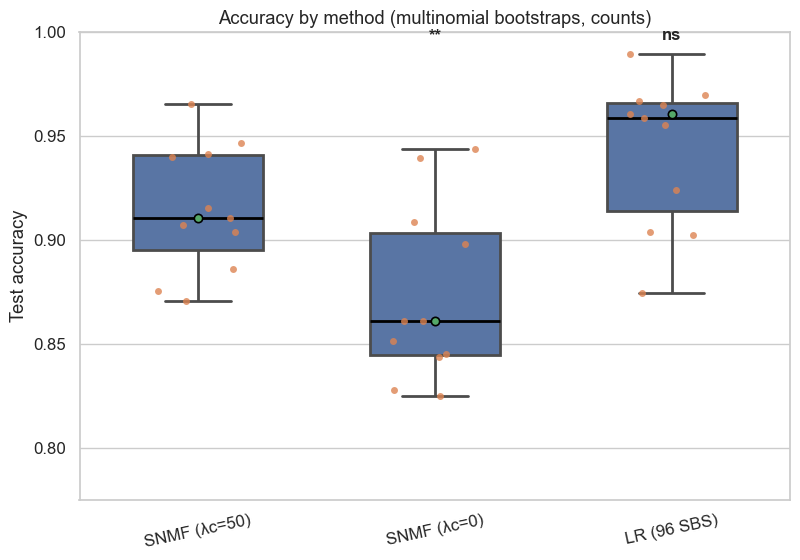


Summary (median, mean ± std):
 method_full  median  mean   std  count
SNMF (λc=50)   0.910 0.915 0.031     11
 SNMF (λc=0)   0.861 0.873 0.043     11
 LR (96 SBS)   0.958 0.943 0.036     11


In [3]:
# ===== SNMF (lc0, lc50) + LR (96SBS) — multinomial only (counts) =====

import os, glob, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

sns.set(style="whitegrid", font_scale=1.1)
%matplotlib inline

# sns.set(style="whitegrid", font_scale=1.15)

# ---------------------------------------------------------------------
# 1) Paths
# ---------------------------------------------------------------------
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# LR results live here (your earlier runs)
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count")

# SNMF sweep results live here (NEW)
results_SNMF_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count_lc_sweep")

fig_dir = os.path.join(project_root, "results", "figures", "sup", "bootstrapping")
os.makedirs(fig_dir, exist_ok=True)

BOOTSTRAP = "multinomial"

# ---------------------------------------------------------------------
# 2) Load SNMF results (lc0 and lc50) — multinomial only
#    Fix: avoid lc50 accidentally matching lc500, etc.
# ---------------------------------------------------------------------
def load_snmf(bootstrap: str, lc_value: int, method_label: str) -> pd.DataFrame:
    # 1) exact expected path first
    exact = os.path.join(results_SNMF_root, f"SNMF_{bootstrap}_lc{lc_value}_full.csv")
    if os.path.exists(exact):
        fpath = exact
    else:
        # 2) fallback: glob then regex-filter to exact lc token
        pat = os.path.join(results_SNMF_root, f"SNMF_{bootstrap}_lc*_full.csv")
        candidates = glob.glob(pat)

        # keep only filenames that contain "_lc{lc_value}_" exactly (or lc{v}.csv or end)
        rx = re.compile(rf"_lc{lc_value}(?:_|\.|$)")
        candidates = [p for p in candidates if rx.search(os.path.basename(p))]

        if not candidates:
            raise FileNotFoundError(
                f"No SNMF file found for {bootstrap} lc={lc_value}.\n"
                f"Tried exact: {exact}\n"
                f"And filtered glob: {pat}"
            )

        # if multiple exact matches exist, pick the newest modified file
        fpath = max(candidates, key=os.path.getmtime)

    df = pd.read_csv(fpath)

    # normalize columns to match plotting code
    rename_map = {
        "accuracy_test": "acc_test",
        "accuracy": "acc_test",
        "f1_test": "f1",
        "recall_test": "rec",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    df["bootstrap"] = bootstrap
    df["lambda_c"] = lc_value
    df["method_full"] = method_label
    df["_source_file"] = os.path.basename(fpath)

    print(f"✅ Loaded SNMF: {fpath} ({len(df)} rows)")
    return df

df_snmf0  = load_snmf(BOOTSTRAP, 0,  "SNMF (λc=0)")
df_snmf50 = load_snmf(BOOTSTRAP, 50, "SNMF (λc=50)")

# ---------------------------------------------------------------------
# 3) Load LR (96 SBS) results — multinomial only
# ---------------------------------------------------------------------
lr_dir  = os.path.join(results_root, f"LR_96sbs_{BOOTSTRAP}")
lr_file = os.path.join(lr_dir, "lr_96sbs_all_splits_CV.csv")
if not os.path.exists(lr_file):
    raise FileNotFoundError(f"Missing LR file: {lr_file}")

df_lr = pd.read_csv(lr_file)
df_lr = df_lr.rename(columns={"accuracy": "acc_test"})
df_lr["bootstrap"] = BOOTSTRAP
df_lr["method_full"] = "LR (96 SBS)"
df_lr["_source_file"] = os.path.basename(lr_file)

print(f"✅ Loaded LR: {lr_file} ({len(df_lr)} rows)")

# ---------------------------------------------------------------------
# 4) Combine + enforce order
# ---------------------------------------------------------------------
df_all = pd.concat([df_snmf50, df_snmf0, df_lr], ignore_index=True, sort=False)

order = ["SNMF (λc=50)", "SNMF (λc=0)", "LR (96 SBS)"]
df_all["method_full"] = pd.Categorical(df_all["method_full"], categories=order, ordered=True)

if "acc_test" not in df_all.columns:
    raise ValueError("Could not find/construct 'acc_test' in the combined dataframe.")

# ---------------------------------------------------------------------
# 5) Wilcoxon signed-rank tests vs SNMF (lc50)
#    (pairs by split if available, else uses raw vectors)
# ---------------------------------------------------------------------
def wilcoxon_vs_ref(df: pd.DataFrame, ref_method: str, other_method: str) -> tuple[float, str]:
    ref = df[df["method_full"] == ref_method]
    oth = df[df["method_full"] == other_method]

    if len(ref) < 2 or len(oth) < 2:
        return (np.nan, "na")

    if "split" in ref.columns and "split" in oth.columns:
        common = np.intersect1d(ref["split"].unique(), oth["split"].unique())
        x = ref[ref["split"].isin(common)].sort_values("split")["acc_test"].to_numpy()
        y = oth[oth["split"].isin(common)].sort_values("split")["acc_test"].to_numpy()
    else:
        x = ref["acc_test"].to_numpy()
        y = oth["acc_test"].to_numpy()

    try:
        stat, p = wilcoxon(x, y, alternative="greater", zero_method="wilcox")
    except ValueError:
        p = np.nan

    sig = "***" if (p == p and p < 0.001) else "**" if (p == p and p < 0.01) else "*" if (p == p and p < 0.05) else "ns"
    return (p, sig)

ref_method = "SNMF (λc=50)"
stats_results = {}
for m in order:
    if m == ref_method:
        continue
    p, sig = wilcoxon_vs_ref(df_all, ref_method, m)
    stats_results[m] = (p, sig)

print("\n🔹 Wilcoxon (SNMF λc=50 > other):")
for m, (p, sig) in stats_results.items():
    if p == p:
        print(f"  {ref_method} > {m}: p={p:.3g} ({sig})")
    else:
        print(f"  {ref_method} > {m}: p=NA")

# ---------------------------------------------------------------------
# 6) Plot (3 boxplots + stripplot) + optional highlight split 10
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 5.8))

sns.boxplot(
    data=df_all, x="method_full", y="acc_test",
    order=order, width=0.55, showfliers=True,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="black"),
    flierprops=dict(marker="o", markersize=5, linestyle="none"),
    ax=ax
)

sns.stripplot(
    data=df_all, x="method_full", y="acc_test",
    order=order, size=5, alpha=0.8, jitter=0.18,
    ax=ax
)

# highlight split 10 if present
if "split" in df_all.columns:
    df_split10 = df_all[df_all["split"] == 10]
    if not df_split10.empty:
        sns.stripplot(
            data=df_split10, x="method_full", y="acc_test",
            order=order, size=6, alpha=1.0, jitter=0.18,
            edgecolor="black", linewidth=1.2,
            ax=ax
        )
        print(f"✅ Highlighted {len(df_split10)} points from split 10")

ax.set_ylabel("Test accuracy")
ax.set_xlabel("")
ax.set_title("Accuracy by method (multinomial bootstraps, counts)")

# significance stars (placed above each competitor)
ymax = float(np.nanmax(df_all["acc_test"]))
y = min(0.995, max(0.80, ymax + 0.02))
for i, m in enumerate(order):
    if m == ref_method:
        continue
    p, sig = stats_results.get(m, (np.nan, "na"))
    ax.text(i, y, sig, ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(max(0.5, float(np.nanmin(df_all["acc_test"])) - 0.05), 1.0)
plt.xticks(rotation=12)
plt.tight_layout()

fig_path = os.path.join(fig_dir, "accuracy_by_method_multinomial_counts_lc0_lc50_lr.pdf")
plt.savefig(fig_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"\n✅ Saved figure to: {fig_path}")
plt.show()

# ---------------------------------------------------------------------
# 7) Summary table
# ---------------------------------------------------------------------
summary = (
    df_all.groupby("method_full")["acc_test"]
    .agg(["median", "mean", "std", "count"])
    .reset_index()
)
summary[["median", "mean", "std"]] = summary[["median", "mean", "std"]].round(3)

print("\nSummary (median, mean ± std):")
print(summary.to_string(index=False))


✅ Loaded SNMF k=5: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep/SNMF_multinomial_lc50_full.csv (11 rows)
✅ Loaded SNMF k=5: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep/SNMF_multinomial_lc0_full.csv (11 rows)
✅ Loaded SNMF k=7: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep_k7/SNMF_multinomial_lc50_full.csv (11 rows)
✅ Loaded SNMF k=7: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count_lc_sweep_k7/SNMF_multinomial_lc0_full.csv (11 rows)
✅ Loaded LR: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_count/LR_96sbs_multinomial/lr_96sbs_all_splits_CV.csv (11 rows)

🔹 Wilcoxon within-k (SNMF λc=50 > λc=0):
  k=5: p=0.00146 (**), n_pairs=11
  k=7: p=0.0415 (*), n_pairs=11

✅ Saved figure to: /Users/sande/Projects/SNMF/results/figures/sup/bootstrapping/accuracy_by_method_multinomial_counts_lc0_lc50_lr_k5_k7.pdf


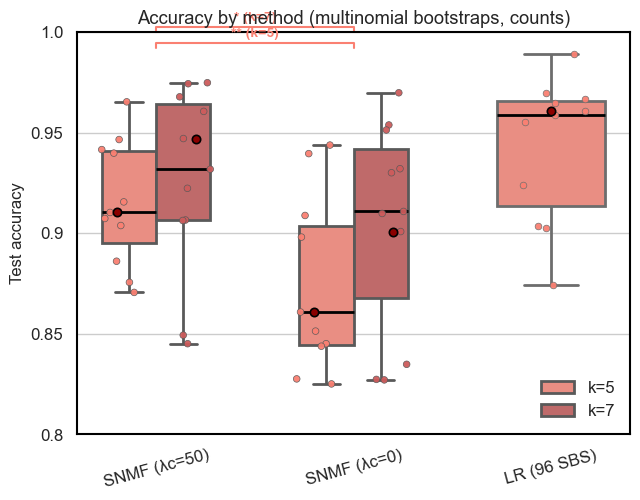


Summary (median, mean ± std):
 method_full k_label  median  mean   std  count
SNMF (λc=50)     k=5   0.910 0.915 0.031     11
SNMF (λc=50)     k=7   0.932 0.926 0.046     11
SNMF (λc=50)    k=NA     NaN   NaN   NaN      0
 SNMF (λc=0)     k=5   0.861 0.873 0.043     11
 SNMF (λc=0)     k=7   0.911 0.904 0.052     11
 SNMF (λc=0)    k=NA     NaN   NaN   NaN      0
 LR (96 SBS)     k=5     NaN   NaN   NaN      0
 LR (96 SBS)     k=7     NaN   NaN   NaN      0
 LR (96 SBS)    k=NA   0.958 0.943 0.036     11


In [10]:
# ===== SNMF (lc0, lc50) + LR (96SBS) — multinomial only (counts) =====
# Fixes split-10 highlighting (exactly ONE point per method×k), and adds Wilcoxon:
#   - within k=5:  lc50 vs lc0
#   - within k=7:  lc50 vs lc0
# (No cross-k tests; no LR in significance.)

import os, glob, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

sns.set(style="whitegrid", font_scale=1.1)
%matplotlib inline

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count")
results_SNMF_root_k5 = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count_lc_sweep")
results_SNMF_root_k7 = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_count_lc_sweep_k7")

fig_dir = os.path.join(project_root, "results", "figures", "sup", "bootstrapping")
os.makedirs(fig_dir, exist_ok=True)

BOOTSTRAP = "multinomial"

def load_snmf_from_root(results_root: str, bootstrap: str, lc_value: int, k_label: str, method_label: str) -> pd.DataFrame:
    exact = os.path.join(results_root, f"SNMF_{bootstrap}_lc{lc_value}_full.csv")
    if os.path.exists(exact):
        fpath = exact
    else:
        pat = os.path.join(results_root, f"SNMF_{bootstrap}_lc*_full.csv")
        candidates = glob.glob(pat)
        rx = re.compile(rf"_lc{lc_value}(?:_|\.|$)")
        candidates = [p for p in candidates if rx.search(os.path.basename(p))]
        if not candidates:
            raise FileNotFoundError(
                f"No SNMF file found for {bootstrap} lc={lc_value} under:\n  {results_root}\n"
                f"Tried exact: {exact}\nAnd filtered glob: {pat}"
            )
        fpath = max(candidates, key=os.path.getmtime)

    df = pd.read_csv(fpath)

    rename_map = {
        "accuracy_test": "acc_test",
        "accuracy": "acc_test",
        "f1_test": "f1",
        "recall_test": "rec",
        "reconstruction_error": "rec",
        "reconstruction": "rec",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    df["bootstrap"] = bootstrap
    df["lambda_c"] = lc_value
    df["k_label"] = k_label
    df["method_full"] = method_label
    df["_source_file"] = os.path.basename(fpath)

    print(f"✅ Loaded SNMF {k_label}: {fpath} ({len(df)} rows)")
    return df

# --- SNMF k=5 ---
df_snmf50_k5 = load_snmf_from_root(results_SNMF_root_k5, BOOTSTRAP, 50, "k=5", "SNMF (λc=50)")
df_snmf0_k5  = load_snmf_from_root(results_SNMF_root_k5, BOOTSTRAP, 0,  "k=5", "SNMF (λc=0)")

# --- SNMF k=7 ---
df_snmf50_k7 = load_snmf_from_root(results_SNMF_root_k7, BOOTSTRAP, 50, "k=7", "SNMF (λc=50)")
df_snmf0_k7  = load_snmf_from_root(results_SNMF_root_k7, BOOTSTRAP, 0,  "k=7", "SNMF (λc=0)")

# --- LR ---
lr_dir  = os.path.join(results_root, f"LR_96sbs_{BOOTSTRAP}")
lr_file = os.path.join(lr_dir, "lr_96sbs_all_splits_CV.csv")
if not os.path.exists(lr_file):
    raise FileNotFoundError(f"Missing LR file: {lr_file}")

df_lr = pd.read_csv(lr_file).rename(columns={"accuracy": "acc_test"})
df_lr["bootstrap"] = BOOTSTRAP
df_lr["k_label"] = "k=NA"
df_lr["method_full"] = "LR (96 SBS)"
df_lr["_source_file"] = os.path.basename(lr_file)
print(f"✅ Loaded LR: {lr_file} ({len(df_lr)} rows)")

# --- Combine ---
df_all = pd.concat(
    [df_snmf50_k5, df_snmf0_k5, df_snmf50_k7, df_snmf0_k7, df_lr],
    ignore_index=True, sort=False
)

order = ["SNMF (λc=50)", "SNMF (λc=0)", "LR (96 SBS)"]
df_all["method_full"] = pd.Categorical(df_all["method_full"], categories=order, ordered=True)

if "acc_test" not in df_all.columns:
    raise ValueError("Could not find/construct 'acc_test' in the combined dataframe.")

df_plot = df_all[df_all["bootstrap"] == BOOTSTRAP].copy()

# ---------------------------------------------------------------------
# Significance: within k=5 (lc50 vs lc0) and within k=7 (lc50 vs lc0)
# ---------------------------------------------------------------------
def wilcoxon_lc50_gt_lc0_within_k(df: pd.DataFrame, k_label: str) -> tuple[float, str, int]:
    sub = df[df["k_label"] == k_label].copy()
    a = sub[sub["method_full"] == "SNMF (λc=50)"]
    b = sub[sub["method_full"] == "SNMF (λc=0)"]

    if len(a) < 2 or len(b) < 2:
        return (np.nan, "na", 0)

    # pair by split if available; else pair by row order
    if "split" in a.columns and "split" in b.columns:
        common = np.intersect1d(a["split"].unique(), b["split"].unique())
        a2 = a[a["split"].isin(common)].sort_values("split")["acc_test"].to_numpy()
        b2 = b[b["split"].isin(common)].sort_values("split")["acc_test"].to_numpy()
    else:
        n = min(len(a), len(b))
        a2 = a["acc_test"].to_numpy()[:n]
        b2 = b["acc_test"].to_numpy()[:n]

    n_pairs = len(a2)
    try:
        stat, p = wilcoxon(a2, b2, alternative="greater", zero_method="wilcox")
    except ValueError:
        p = np.nan

    sig = "***" if (p == p and p < 0.001) else "**" if (p == p and p < 0.01) else "*" if (p == p and p < 0.05) else "ns"
    return (p, sig, n_pairs)

p5, sig5, n5 = wilcoxon_lc50_gt_lc0_within_k(df_plot, "k=5")
p7, sig7, n7 = wilcoxon_lc50_gt_lc0_within_k(df_plot, "k=7")

print("\n🔹 Wilcoxon within-k (SNMF λc=50 > λc=0):")
print(f"  k=5: p={p5:.3g} ({sig5}), n_pairs={n5}" if p5 == p5 else f"  k=5: p=NA, n_pairs={n5}")
print(f"  k=7: p={p7:.3g} ({sig7}), n_pairs={n7}" if p7 == p7 else f"  k=7: p=NA, n_pairs={n7}")

# ---------------------------------------------------------------------
# Plot
#   - SNMF: hue=k_label (k=5/k=7) => 2 boxes per SNMF method
#   - LR: single box
#   - Split-10 highlight: EXACTLY ONE dot per (method_full, k_label), and ONE for LR
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.6, 5.2))

df_snmf = df_plot[df_plot["method_full"].isin(["SNMF (λc=50)", "SNMF (λc=0)"])].copy()
df_lr_p = df_plot[df_plot["method_full"] == "LR (96 SBS)"].copy()

sns.boxplot(
    data=df_snmf, x="method_full", y="acc_test",
    order=order[:2],
    hue="k_label", hue_order=["k=5", "k=7"],
    palette=["salmon", "indianred"],
    width=0.55, showfliers=True,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="black"),
    flierprops=dict(marker="o", markersize=5, linestyle="none"),
    ax=ax
)
sns.stripplot(
    data=df_snmf, x="method_full", y="acc_test",
    order=order[:2],
    hue="k_label", hue_order=["k=5", "k=7"],
    palette=["salmon", "indianred"],
    linewidth=0.5, edgecolor="gray",
    dodge=True, jitter=0.18, size=4.8, alpha=0.95,
    ax=ax
)

sns.boxplot(
    data=df_lr_p, x="method_full", y="acc_test",
    order=["LR (96 SBS)"],
    color="salmon", width=0.55, showfliers=True,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="black"),
    flierprops=dict(marker="o", markersize=5, linestyle="none"),
    ax=ax
)
sns.stripplot(
    data=df_lr_p, x="method_full", y="acc_test",
    order=["LR (96 SBS)"],
    color="salmon", jitter=0.18, size=4.8, alpha=0.95,
    linewidth=0.5, edgecolor="gray",
    ax=ax
)

# ---- highlight split 10: exactly one point per (method_full, k_label) and one for LR
if "split" in df_plot.columns:
    df10 = df_plot[df_plot["split"] == 10].copy()
    if not df10.empty:
        # SNMF: pick ONE row per (method, k)
        df10_snmf = df10[df10["method_full"].isin(["SNMF (λc=50)", "SNMF (λc=0)"])].copy()
        if not df10_snmf.empty:
            # if there are duplicates (e.g. CV reps), collapse to 1 by taking the first after sorting
            df10_snmf = df10_snmf.sort_values(["method_full", "k_label", "_source_file"]).groupby(
                ["method_full", "k_label"], as_index=False
            ).head(1)

            sns.stripplot(
                data=df10_snmf, x="method_full", y="acc_test",
                order=order[:2],
                hue="k_label", hue_order=["k=5", "k=7"],
                palette=["darkred", "darkred"],  # both hues darkred for highlight
                dodge=True, jitter=0.18, size=6, alpha=1.0,
                edgecolor="black", linewidth=1.2,
                ax=ax
            )

        # LR: pick ONE row
        df10_lr = df10[df10["method_full"] == "LR (96 SBS)"].copy()
        if not df10_lr.empty:
            df10_lr = df10_lr.sort_values(["_source_file"]).head(1)
            sns.stripplot(
                data=df10_lr, x="method_full", y="acc_test",
                order=["LR (96 SBS)"],
                color="darkred", jitter=0.18, size=6, alpha=1.0,
                edgecolor="black", linewidth=1.2,
                ax=ax
            )

# clean legend (keep only k=5/k=7 once)
handles, labels = ax.get_legend_handles_labels()
keep = []
seen = set()
for h, l in zip(handles, labels):
    if l in ["k=5", "k=7"] and l not in seen:
        keep.append((h, l))
        seen.add(l)
if keep:
    ax.legend([h for h, _ in keep], [l for _, l in keep], title="", frameon=False, loc="lower right")
elif ax.get_legend() is not None:
    ax.get_legend().remove()

# labels / style
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0.8, 1.0)
ax.set_yticks([0.8, 0.85, 0.9, 0.95, 1.0])
ax.set_yticklabels(["0.8", "0.85", "0.9", "0.95", "1.0"])
ax.set_title("Accuracy by method (multinomial bootstraps, counts)")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

# significance bars: ONLY within-k comparisons (lc50 vs lc0), placed above SNMF groups
# We draw two short brackets above the SNMF pair region, one for k=5 and one for k=7.
# x positions: 0 = SNMF(50), 1 = SNMF(0)
y_base = 0.992
dy = 0.008

def draw_bracket(x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y, y + dy/3, y + dy/3, y], lw=1.5, c="salmon", clip_on=False)
    ax.text((x1 + x2) / 2, y + dy/2, text, ha="center", va="bottom",
            color="salmon", fontsize=10, fontweight="bold", clip_on=False)

# k=5 bracket
draw_bracket(0, 1, y_base, f"{sig5} (k=5)")
# k=7 bracket slightly above
draw_bracket(0, 1, y_base + dy, f"{sig7} (k=7)")

plt.xticks(rotation=15)
plt.tight_layout()

fig_path = os.path.join(fig_dir, "accuracy_by_method_multinomial_counts_lc0_lc50_lr_k5_k7.pdf")
plt.savefig(fig_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"\n✅ Saved figure to: {fig_path}")
plt.show()

# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------
summary = (
    df_plot.groupby(["method_full", "k_label"])["acc_test"]
    .agg(["median", "mean", "std", "count"])
    .reset_index()
)
summary[["median", "mean", "std"]] = summary[["median", "mean", "std"]].round(3)

print("\nSummary (median, mean ± std):")
print(summary.to_string(index=False))


In [39]:
df_all

,split,bootstrap,lambda_c,acc_test,f1,rec,Lrec_train,Lce_train,Ltot_train,stability,...,epochs_mean,k,lr,lambda_p,reps,method,f1_score,recall,best_C,method_full
0,0,multinomial,0.0,0.93075,0.931191,4.489919,0.265143,0.183146,0.265143,1.0,...,21000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
1,1,multinomial,0.0,0.98525,0.985249,4.214739,0.264134,0.118442,0.264134,1.0,...,15000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
2,2,multinomial,0.0,0.92400,0.924734,4.524746,0.261939,0.188743,0.261939,1.0,...,15000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
3,3,multinomial,0.0,0.93375,0.933337,4.068469,0.272800,0.234068,0.272800,1.0,...,21000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
4,4,multinomial,0.0,0.96875,0.968523,4.288735,0.272282,0.154910,0.272282,1.0,...,15000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,6,dirichlet,NaN,0.86100,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.859672,0.86100,0.010000,LR (COSMIC exposures)
84,7,dirichlet,NaN,0.89075,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.889964,0.89075,0.010000,LR (COSMIC exposures)
85,8,dirichlet,NaN,0.89225,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.891290,0.89225,0.158489,LR (COSMIC exposures)
86,9,dirichlet,NaN,0.89650,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.896114,0.89650,0.010000,LR (COSMIC exposures)


# SNMF Cell-line - Analysis